# Error-Semitransparent Gates on a Binomial Kitten Code

*Replication of Roy, Wetherbee & Fatemi, arXiv:2603.15356: logical gates on a binomial kitten
code that stay error-transparent while the gate is still running. Three gates, `X`, `H`, and
`T`; two variants each -- `est`, the full $C_1{+}C_2{+}C_3{+}C_4$ objective, and `ord`, the same
code path with $w_2 = w_3 = 0$ -- all six cold-started at **2000 L-BFGS-B iterations per stage**
(`T`/`ord` converges on `pgtol` in 16 iterations and never needs the budget), all six trained at
**seed 0**, with no replicate seeds run -- see [limitation 5](#9).*

## Summary

**The claim being tested.** A gate is *error-transparent* if a photon loss that happens
mid-gate commutes through the rest of the evolution: the evolved error state at time $t$ stays
equal to the photon-loss image of the evolved code state at time $t$, so the same recovery map
still corrects it at $t = T$. An ordinary gate scrambles the error space against the code space
and the loss becomes uncorrectable. The paper trains transparent gates on a binomial kitten code
and reports transparency holding to $F_{\mathrm{ET}} \approx 0.83$.

**What this notebook reports.** The six delivered pulses, scored through an *independent*
propagator, against the three time-resolved transparency metrics of the paper's Eqs. 6--8:

| gate | $F_1$ (EsT) | $F_{\mathrm{ET}}$ (EsT) | $L_{E_j}$ EsT / Ord | Ord:EsT on $L$ | Ord:EsT on $\eta$ |
|---|---|---|---|---|---|
| X | 0.99929 | 0.730 | 0.148 / 0.466 | 3.15x | 2.99x |
| H | 0.99968 | 0.818 | 0.113 / 0.528 | 4.65x | 4.58x |
| T | 0.99998 | 0.945 | $2.8{\times}10^{-6}$ / $2.3{\times}10^{-4}$ | 80.97x | 7.12x |

Every number above is recomputed live in [§5](#5); none is transcribed into the code.

Three findings carry the document:

1. **Transparency is cheap in fidelity.** On X and H, EsT buys a 3.0--4.6x improvement on the
   error-space metrics for $\sim 7\times10^{-4}$ of ordinary infidelity. The trade is the
   intended one, not a defect: `ord` spends its entire budget on $C_1$ and has nothing left to
   spend elsewhere.
2. **The H-vs-X gap is gate-dependent, not budget-dependent.** At an *identical* 2000-it/stage
   cold start with identical per-iteration cost, H reaches $F_{\mathrm{ET}} = 0.818$ against X's
   0.730 and beats X on every error-space metric at *higher* $F_1$. Iteration count was the
   obvious suspect and has been ruled out ([§9](#9), limitation 1). What is left is not yet
   identified.
3. **T is not a scaled-down X/H -- it is a different regime.** T is a pure qubit-frame phase
   gate: `CONTROL_MASK` zeroes the cavity drive exactly, `ord` reaches $F_1 = 1.00000$ in 16
   iterations rather than exhausting the 2000-iteration budget, and both variants sit at the
   same `max_active_fock = 4` -- unlike X/H, T's two variants *are* like-for-like on the
   fair-comparison criterion ([§9](#9), limitation 2). Against that easier baseline, EsT's
   advantage is far larger than X/H's: 80.97x on $L$, 7.12x on $\eta$. Read this as a property
   of how little transparency-scrambling a diagonal gate needs to begin with, not as evidence
   T's EsT pulse is categorically better-behaved than X's or H's -- see [§6.1](#6.1).

**Out of scope.** The `LE` control variant is not implemented, and neither is the AQEC recovery
pulse behind the paper's Figs. 4--5. See [§9](#9).

**Reading order.** [§1](#1) fixes the device and the code, [§2](#2) derives the objective and
records where it deviates from the paper's printed equations, [§3](#3) shows the code that runs
it, [§4](#4)--[§6](#6) are the results, [§7](#7) is validation, [§8](#8) documents a
second training pipeline built on a hand-derived analytic gradient, and [§9](#9) is the
caveat list.
A reader who only wants the numbers can go straight to [§5](#5).

## Preamble -- imports and knobs

Imports, paths, and the two switches that control what this notebook recomputes. [§3](#3)
documents the training API itself; this cell only makes it importable.

In [1]:
import os
import sys
import json
import glob
import subprocess

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# EST.grape_jax sets jax_enable_x64 at import time, so it must come before any
# other JAX use in the session.
from EST import grape_jax
from EST import device, kitten_code, train_est, diagnostics, subspace_evolution
from core.grape_core import make_ops

# --- knobs ---
RUN_TRAINING      = False   # True retrains from scratch: 0.01-10.1 h PER RUN, six runs.
REGENERATE_FIGURES = True   # recompute the analysis figures and overwrite figures/est/, tables/
RUN_TESTS         = True    # run EST/test_grape_jax.py as a subprocess in section 7 (~30 s)
GATES             = ["X", "H", "T"]
N_C               = 20      # scoring truncation; the trained one
# -------------

PULSE_DIR = os.path.join(REPO_ROOT, "pulses", "est")
FIG_DIR   = os.path.join(REPO_ROOT, "figures", "est")
TABLE_DIR = os.path.join(REPO_ROOT, "tables")
LOG_DIR   = os.path.join(REPO_ROOT, "logs")

EST_COLOR, ORD_COLOR = "#2a6fb5", "#c4453c"   # matched to EST/diagnostics.py

# Figures are SAVED and then displayed with IPython.display.Image rather than with
# display(fig): EST/diagnostics.plot_fig1 and EST/subspace_evolution.plot_fig1a both call
# matplotlib.use("Agg") from inside the function, so an inline-rendered figure would depend
# on cell execution order. width= is also how each figure is held to a moderate on-page size.
def show(path, width=900):
    display(Image(filename=path, width=width))

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("repo root:", REPO_ROOT)

repo root: /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE


In [2]:
import scipy, jax, matplotlib
for name, mod in [("numpy", np), ("scipy", scipy), ("jax", jax),
                  ("matplotlib", matplotlib), ("pandas", pd)]:
    print(f"{name:12s} {mod.__version__}")
print(f"{'python':12s} {sys.version.split()[0]}")
print(f"{'x64 enabled':12s} {jax.config.jax_enable_x64}")

numpy        2.0.2
scipy        1.13.1
jax          0.4.30
matplotlib   3.9.4
pandas       2.3.3
python       3.9.6
x64 enabled  True


<a id="1"></a>
# 1. The device and the code

### 1.1 System model

A transmon $B$ dispersively coupled to a storage cavity $A$, with drift

$$
H_0 \;=\; \chi\, n_A n_B \;+\; \frac{K_a}{2} A^{\dagger 2} A^2 \;+\; \frac{K'}{6} A^{\dagger 3} A^3
\;+\; \frac{\chi'}{2} n_B A^{\dagger 2} A^2 \;+\; \frac{K_q}{2} B^{\dagger 2} B^2 ,
$$

and four real controls $[\,C_I, C_Q, T_I, T_Q\,]$ entering as $\varepsilon_C = C_I + iC_Q$ on the
cavity and $\varepsilon_T = T_I + iT_Q$ on the transmon.

`EST/device.py` builds this rather than reusing `core.grape_core.make_hamiltonian`, and differs
from it in two ways that matter:

- the second-order cavity self-Kerr $K'$, which the main pipeline's $H_0$ does not carry at all;
- `n_t >= 3` is **enforced with a raise**. The main pipeline silently drops the anharmonicity
  term at `n_t = 2`; here that would discard $K_q/2\pi = -180$ MHz, the largest number in the
  table below.

The `chi`/`Kerr` globals in `core/grape_core.py` are never touched -- every pulse in `pulses/`
and the whole `validation/` layer is scored against those, and mutating them to run EsT work
would silently invalidate the other track.

In [3]:
tp = device.two_pi
rows = [
    ("$\\chi/2\\pi$",        device.chi   / tp * 1e3, "MHz -> kHz", "dispersive qubit-cavity coupling"),
    ("$K_a/2\\pi$",          device.K_a   / tp * 1e3, "MHz -> kHz", "cavity self-Kerr"),
    ("$K'/2\\pi$",           device.K_p   / tp * 1e6, "MHz -> Hz",  "second-order cavity self-Kerr"),
    ("$\\chi'/2\\pi$",       device.chi_p / tp * 1e3, "MHz -> kHz", "second-order dispersive shift"),
    ("$K_q/2\\pi$",          device.K_q   / tp * 1e3, "MHz -> kHz", "transmon anharmonicity"),
]
tbl1a = pd.DataFrame(
    [(n, f"{v:,.1f}", u.split(" -> ")[1], d) for n, v, u, d in rows],
    columns=["parameter", "value", "unit", "meaning"])

tbl1b = pd.DataFrame([
    ("$T_1^C$ / $T_2^C$",  f"{device.T1_CAVITY:.0f} / {device.T2_CAVITY:.0f}", "us",
     "cavity coherence (not modelled -- training is lossless)"),
    ("$T_1^q$ / $T_2^{Ramsey}$ / $T_2^{echo}$",
     f"{device.T1_QUBIT:.0f} / {device.T2_RAMSEY_QUBIT:.0f} / {device.T2_ECHO_QUBIT:.0f}", "us",
     "transmon coherence (not modelled)"),
    ("$dt$",               f"{device.DT*1e3:.0f}", "ns", "piecewise-constant step"),
    ("$N$",                f"{device.n_steps('X')}", "steps", "X and H are 1.0 us gates"),
    ("band",               f"{device.BAND_MHZ[0]:.0f} .. {device.BAND_MHZ[1]:.0f}", "MHz",
     "hard cutoff, both drives"),
    ("$\\varepsilon_{max}$", f"{device.EPS_MAX:.2f}", "rad/us",
     f"= 2*pi*{device.EPS_MAX/tp:.0f} MHz; caps the QUADRATURE PAIR norm"),
    ("ramp",               f"{device.RAMP_NS:.0f}", "ns", "Gaussian rise and fall"),
    ("$n_t$",              f"{device.N_T}", "levels", "enforced >= 3"),
    ("$n_c$ trained",      "20", "levels", "single truncation; validated over 16..28 in section 7"),
], columns=["parameter", "value", "unit", "meaning"])

print("Table I constants (built from EST/device.py, not transcribed):")
display(tbl1a)
print("\nRun parameters:")
display(tbl1b)

Table I constants (built from EST/device.py, not transcribed):


,parameter,value,unit,meaning
0,$\chi/2\pi$,"-3,660.0",kHz,dispersive qubit-cavity coupling
1,$K_a/2\pi$,-22.0,kHz,cavity self-Kerr
2,$K'/2\pi$,590.0,Hz,second-order cavity self-Kerr
3,$\chi'/2\pi$,39.0,kHz,second-order dispersive shift
4,$K_q/2\pi$,"-180,000.0",kHz,transmon anharmonicity



Run parameters:


,parameter,value,unit,meaning
0,$T_1^C$ / $T_2^C$,180 / 290,us,cavity coherence (not modelled -- training is ...
1,$T_1^q$ / $T_2^{Ramsey}$ / $T_2^{echo}$,70 / 30 / 84,us,transmon coherence (not modelled)
2,$dt$,1,ns,piecewise-constant step
3,$N$,1000,steps,X and H are 1.0 us gates
4,band,-50 .. 50,MHz,"hard cutoff, both drives"
5,$\varepsilon_{max}$,25.13,rad/us,= 2*pi*4 MHz; caps the QUADRATURE PAIR norm
6,ramp,48,ns,Gaussian rise and fall
7,$n_t$,3,levels,enforced >= 3
8,$n_c$ trained,20,levels,single truncation; validated over 16..28 in se...


**Table 1. Device and run parameters.** The upper block is the paper's Table I, read back out of
`EST/device.py`'s module constants and divided by `two_pi` -- so it cannot drift from what the
Hamiltonian actually uses. The lower block is everything the training runs fixed.

> $\varepsilon_{\max}$ caps the **quadrature pair norm** $\sqrt{I^2+Q^2}$, not each quadrature
> separately. That circularity is the reason the amplitude limit has to be a penalty rather than
> an L-BFGS-B box constraint -- see [§2.4](#2.4).

### 1.2 The binomial kitten code

$$
|0_L\rangle = \tfrac{1}{\sqrt2}\big(|0\rangle + |4\rangle\big), \qquad |1_L\rangle = |2\rangle,
\qquad\qquad |0_E\rangle = |3\rangle, \qquad |1_E\rangle = |1\rangle .
$$

The code exists because of one coincidence: $a|0_L\rangle = \sqrt2\,|3\rangle$ and
$a|1_L\rangle = \sqrt2\,|1\rangle$ carry **equal weight**, so $a$ restricted to the code space is
$\sqrt2$ times an isometry. A single photon loss therefore maps the logical qubit rigidly onto
the error space instead of deforming it, and the error words $\{|3\rangle, |1\rangle\}$ can be
labelled so that code column $j$ maps to error column $j$.

In [4]:
n_t, n_c = device.N_T, N_C
B = kitten_code.logical_basis(n_t, n_c)     # (n, 2): columns |0_L>, |1_L>
E = kitten_code.error_basis(n_t, n_c)       # (n, 2): columns |0_E>, |1_E>
A_op, _ = make_ops(n_t, n_c)
n_op = A_op.conj().T @ A_op

def fock_support(col, tol=1e-9):
    """Fock-basis support of a state living in the transmon |g> block."""
    amps = col.reshape(n_t, n_c)[0]
    return {k: round(float(np.real(a)), 4) for k, a in enumerate(amps) if abs(a) > tol}

rows = []
for j, lbl in enumerate(["|0_L>", "|1_L>"]):
    img = A_op @ B[:, j]
    nrm = float(np.linalg.norm(img))
    rows.append({
        "code word": lbl,
        "Fock support": str(fock_support(B[:, j])),
        "<n>": round(float(np.real(np.vdot(B[:, j], n_op @ B[:, j]))), 6),
        "|| a|psi> ||": round(nrm, 6),
        "normalized loss image": str(fock_support(img / nrm)),
        "|<E_j| a psi >|": round(float(abs(np.vdot(E[:, j], img / nrm))), 12),
    })
display(pd.DataFrame(rows))

print("equal-weight coincidence, || a|0_L> || == || a|1_L> ||  ->",
      bool(np.isclose(np.linalg.norm(A_op @ B[:, 0]), np.linalg.norm(A_op @ B[:, 1]))))
print("code words share <n>, so <0_L|n|1_L> = 0                ->",
      bool(np.isclose(np.vdot(B[:, 0], n_op @ B[:, 1]), 0.0)))
_ = kitten_code.error_cardinals(n_t, n_c)   # carries the live assertion on the coincidence
print("kitten_code.error_cardinals() live assertion             -> passed")

,code word,Fock support,<n>,|| a|psi> ||,normalized loss image,|<E_j| a psi >|
0,|0_L>,"{0: 0.7071, 4: 0.7071}",2.0,1.414214,{3: 1.0},1.0
1,|1_L>,{2: 1.0},2.0,1.414214,{1: 1.0},1.0


equal-weight coincidence, || a|0_L> || == || a|1_L> ||  -> True
code words share <n>, so <0_L|n|1_L> = 0                -> True
kitten_code.error_cardinals() live assertion             -> passed


**Table 2. The code words and their photon-loss images.** Both code words carry
$\langle n\rangle = 2$ and both lose exactly $\sqrt 2$ of norm under $a$; the normalized image of
code column $j$ is error column $j$ to machine precision.

That last equality is not a convenience -- it is the property `kitten_code.error_cardinals`
asserts at runtime, so that the six *error* cardinals can be built by applying the same
coefficient matrix to the error basis rather than by hand-permuting states. Read its docstring
before reusing that function for a different code, where the coincidence will not hold.

Note also $\langle 0_L | n | 1_L \rangle = 0$: **no superposition of the code words can have
$\langle n\rangle \ne 2$.** That fact reappears in [§4](#4), where it explains why every code
curve in Figure 1 starts at exactly 2 regardless of which pulse is driving it.

<a id="1.3"></a>
### 1.3 Why *semi*-transparent

Exact error transparency is unreachable here, and the paper says so in its App. A. With linear
drives the obstruction is

$$
\Big[\tfrac{K_a}{2}A^{\dagger2}A^2 + \tfrac{\chi'}{2}A^{\dagger2}A^2\,n_B,\; A\Big]
= -\big(K_a + \chi' n_B\big) A^\dagger A^2 ,
$$

which no control in this Hamiltonian can cancel. Transparency is therefore *semi*: the metrics
in [§5](#5) should fall, flatten, and stop somewhere above zero.

**This is the sentence the whole Results section is read against.** A nonzero floor is the
physics of the device, not a convergence failure of the optimizer -- so the result being tested
is the EsT-to-Ord *separation*, never the absolute distance from zero.

<a id="2"></a>
# 2. Methodology

### 2.1 Cost functions

Four terms, combined as $C_{\mathrm{tot}} = \sum_i w_i C_i$ and minimized by L-BFGS-B with the
gradient supplied by JAX reverse-mode autodiff:

| | function in `EST/grape_jax.py` | type | role |
|---|---|---|---|
| $C_1$ | `fidelity_cost` | terminal | ordinary gate infidelity |
| $C_2$ | `et_cost` | running | error-transparency infidelity |
| $C_3$ | `velocity_variance_cost` | running | velocity-variance regularizer |
| $C_4$ | `amplitude_cost` | running | circular drive-amplitude cap |

$$
C_1 = 1 - \frac{1}{M}\sum_{j=1}^{6} \big|\langle \mathrm{target}_j | U(T) | \psi_j\rangle\big|^2 ,
\qquad
C_2 = 1 - \Big\langle \frac{|\langle \psi_{E_j}(t) | a | \psi_C(t)\rangle|^2}
{\langle \psi_C | a^\dagger a | \psi_C\rangle} \Big\rangle_{t,\,j} ,
$$

$$
C_3 = \Big\langle \frac{\mathrm{Var}_t(v)}{(\mathrm{mean}_t\, v)^2} \Big\rangle_j ,
\quad v_i = \frac{2}{dt}\arccos\big|\langle \psi_i | \psi_{i+1}\rangle\big| ,
\qquad
C_4 = \Big\langle \max(|\varepsilon_C| - \varepsilon_{\max}, 0)^2
                + \max(|\varepsilon_T| - \varepsilon_{\max}, 0)^2 \Big\rangle_t .
$$

**Table 3. What each term is for.** $C_1$ is the gate. $C_2$ is the replication target: it
compares the evolved error state against the photon-loss image of the evolved code state *at
every time step*, because transparency is a statement about all of $[0,T]$, not about $T$.
$C_4$ enforces the hardware amplitude limit. $C_3$ is the least obvious of the four and the one
most easily mistaken for decoration.

**Why $C_3$ exists.** $C_2$ has a trivial global minimum: with the drive switched off, nothing
evolves, the error state stays exactly the loss image of the code state, and $C_2 = 0$. An
optimizer handed only $C_1 + C_2$ will happily park the dynamics and buy transparency by not
doing the gate. $C_3$ penalizes non-uniform trajectory speed, which is zero for a parked
trajectory as well -- but the *ratio* $\mathrm{Var}(v)/\mathrm{mean}(v)^2$ is not, so the
normalized form has no reward for slowing down. [§2.3](#2.3) shows the measurement behind this.

$v_i$ is the Anandan--Aharonov speed: it converges to $2\Delta E(t)$ as $dt \to 0$, matched
pointwise to a maximum relative deviation of $2.0\times10^{-3}$. Under $H_0$ alone
$2\Delta E = 0.56$ rad/us, so **99.4% of the trajectory speed in these pulses is drive-induced**.

<a id="2.2"></a>
### 2.2 How fidelity is computed -- in training and in analysis

Ordinary gate fidelity is one formula:

$$
F_1 = \frac{1}{6}\sum_{j=1}^{6}
\bigl|\langle \mathrm{target}_j | U(T) | \psi_j\rangle\bigr|^2 ,
\qquad C_1 = 1 - F_1.
$$

The six states are the Bloch cardinals $\{\pm Z, \pm X, \pm Y\}$. Training minimizes $C_1$
as part of $C_{\mathrm{tot}}$; analysis re-evaluates the same $F_1$ on the saved pulse.
The two evaluations use different propagators on purpose.

| | propagator | what is computed | why this algorithm |
|---|---|---|---|
| training | JAX `expm` | $C_1$ at $t = T$; $C_2$ on the same trajectory | autodiff through `eigh` is singular at degeneracies; `expm` never diagonalizes |
| analysis | `grape_core.step_data` (`eigh`) | the same $F_1$, plus the metrics in [§5](#5) | a second algorithm; agreement is the check that the training number is real |

**Training uses `expm` so the gradient exists.** L-BFGS-B needs
$\partial C_{\mathrm{tot}} / \partial u$. Differentiating an eigendecomposition fails when
two eigenvalues meet -- the same singularity that `core/grape_core.py` already patches by
hand for its analytic adjoint. Autodiff through `jnp.linalg.eigh` would hit it again.
`jax.scipy.linalg.expm` computes $e^{-i\,dt\,H_k}$ without diagonalizing, so that
singularity never appears. $C_2$ is scored on this trajectory because transparency is a
claim about every $t$, not about the endpoint.

**Analysis uses `eigh` so the number can be checked.** A pulse that scores well under its
own propagator and badly under another has a numerics problem, not a physics result.
`EST/diagnostics.py` therefore re-scores with the eigendecomposition already used by the
cat-code pipeline -- the same idea as that pipeline's QuTiP cross-check. The two $F_1$
values agree to $\sim 10^{-13}$; that is measured in [§7](#7), not asserted here.

**Why $F_1$ is a plain average of squared overlaps.** Each term
$|\langle\mathrm{tgt}_j|U|\psi_j\rangle|^2$ is blind to the phase of column $j$. Two
computational-basis targets therefore pin $U|0_L\rangle$ and $U|1_L\rangle$ only up to
independent phases $e^{ia}$ and $e^{ib}$. The difference $a - b$ is a relative phase in
the logical map -- a real error, not a gauge. That is why the cat-code pipeline, which
trains on two states, uses `coherent_fidelity_multi_state`. Six cardinals close the
loophole. For an X gate, if $U|0_L\rangle = e^{ia}|1_L\rangle$ and
$U|1_L\rangle = e^{ib}|0_L\rangle$, then $|\langle +X_L | U | +X_L\rangle| = 1$ forces
$a = b$. Linearity of $U$ pins every other relative phase. Only a global phase remains,
and a global phase does not change $F_1$.


<a id="2.3"></a>
### 2.3 Deviations from the published equations

Three places the implementation does not follow the paper as printed. All three
are deliberate and pinned by tests in `EST/test_grape_jax.py`.

**Table 4. The deviations.**

| # | printed form | what is implemented | why |
|---|---|---|---|
| 1 | $C_2$ divides by $N_{\mathrm{norm}}$ | divides by $N_{\mathrm{norm}}^2$ | the printed form is not a fidelity in $[0,1]$ |
| 2 | $C_3 = \langle\mathrm{Var}_t(v)\rangle_j$ | $\langle\mathrm{Var}_t(v)/\mathrm{mean}_t(v)^2\rangle_j$ | the printed form has units, swamps $C_1$ and $C_2$, and is minimized by parking |
| 3 | Eqs. 6--8 | reconstructed from the transparency conditions | the paper prints the conditions, not a unique metric |

**1. $C_2$ divides by $N_{\mathrm{norm}}^2$.** The paper divides
$|\langle\psi_E|a|\psi_C\rangle|^2$ by
$N_{\mathrm{norm}} = \sqrt{\langle\psi_C|a^\dagger a|\psi_C\rangle}$. That quantity
is not bounded by 1. Cauchy--Schwarz says
$|\langle\psi_E|a|\psi_C\rangle|^2 \le \langle\psi_C|a^\dagger a|\psi_C\rangle$
for a unit-norm error state, so the square is the denominator that makes
$F_{\mathrm{ET}}$ a genuine fidelity. Both variants are scored the same way, so
the EsT:Ord comparison does not depend on this choice.

**2. $C_3$ divides by $\mathrm{mean}(v)^2$.** The printed $C_3$ is the variance
of a speed, so it carries units of $(\mathrm{rad}/\mu\mathrm{s})^2$. On the
trained X pulse that number is $965$. With the paper's $w_3 = 5$--$10$, the
$C_3$ term would be $5\times10^3$--$10^4$ against $C_1, C_2 \in [0,1]$: the
optimizer would minimize the regularizer and ignore the gate.

Worse, the raw form is globally minimized by turning the drive off. Scaling a
trained pulse by $u \to \lambda u$:

| $\lambda$ | 1.0 | 0.5 | 0.1 | 0.01 | 0.0 |
|---|---|---|---|---|---|
| $\mathrm{Var}(v)$ raw | 964.70 | 359.27 | 28.53 | 0.237 | **0.000** |
| $\mathrm{Var}/\mathrm{mean}^2$ | 0.1126 | 0.1213 | 0.2000 | 0.1399 | 0.000 |

Raw $C_3$ falls to exactly $0$ at $\lambda = 0$ -- the parking failure that
[§2.1](#2.1) introduced $C_3$ to prevent. The normalized form stays $O(0.1)$
across three decades of $\lambda$, and only collapses when the drive is exactly
off, where $v$ is constant and both forms are zero. Dividing by
$\mathrm{mean}(v)^2$ is what makes the term penalize *uneven* motion rather than
*slow* motion.

The $2/dt$ in $v_i$ is not the issue. Subdividing the trained pulse $16\times$
moves the raw variance by $0.12\%$; both forms already converge. $v$ is simply
large on this chip: $\mathrm{mean}(v) = 92$ rad/us, of which $99.4\%$ is
drive-induced.

`velocity_variance_cost(..., normalize=False)` still returns the printed form,
for the test that demonstrates the swamping.

**3. Eqs. 6--8 are reconstructed.** The paper states three transparency
conditions. The time-resolved metrics in [§5](#5) -- $\Delta_{\mathrm{QEC}}$,
$L_{E_j}$, $\eta_{E_j,\psi}$ -- are this module's translation of those
conditions, not a transcription of printed formulae. $L$ and $\eta$ are bounded
in $[0,1]$ by construction; $\Delta_{\mathrm{QEC}}$'s normalization, and
$\mathcal{M}$ and $\overline{|\Delta\langle n\rangle|}$ in [§4](#4), are
choices. Both variants are scored identically, so **EsT:Ord ratios are the
result and absolute axis values are not.** That caveat is repeated next to
every ratio in [§4](#4)--[§6](#6).


<a id="2.4"></a>
### 2.4 The constraint chain, and bounds versus penalties

The raw optimizer variable $x$ is turned into a physical pulse by three operations applied
**inside the cost**, so autodiff differentiates through all of them:

$$
x \;\xrightarrow{\ \text{band-limit}\ }\; \xrightarrow{\ \text{ramp}\ }\; \xrightarrow{\ \text{control mask}\ }\; u_{\mathrm{phys}} .
$$

The order is not arbitrary. Measured on white noise at $N = 1000$, $dt = 1$ ns, 48 ns ramp:

| order | out-of-band energy | endpoint amplitude (rel. to mid-pulse) |
|---|---|---|
| project $\to$ ramp | 0.34% | 0.4% |
| ramp $\to$ project | 0% | 23% |

Projecting last gives an exactly band-limited pulse that does not actually start at zero;
projecting first gives a pulse that starts at zero and leaks a third of a percent out of band.
The second failure is the one hardware cares about, so the chain projects first.

**Bounds do not cap amplitude.** `scipy`'s `bounds` act on the raw pre-image $x$, not on
$u_{\mathrm{phys}}$, and the physical cap is *circular* ($\sqrt{I^2+Q^2} \le \varepsilon_{\max}$)
which a per-element box cannot express in any case. At the default `hard_bound = 60`, a
corner-pinned raw variable admits $|\varepsilon|$ up to 84.9 rad/us -- **3.4x the physical cap**
-- so the box never binds and must not be "tightened" in the expectation that the waveform will
follow. The cap is $C_4$'s job, and $C_4$ alone.

**Warm restarts take `--init-x`, not `--init`.** `--init` inverts the constraint chain by
dividing out the ramp envelope, which reaches 0.0066 at the pulse edges and so amplifies them by
up to 151x; the recovered pre-image can land outside the default box. Saving the raw variable
alongside the pulse (`pulses/est/x_*.npy`) makes the restart exact instead.

<a id="2.5"></a>
### 2.5 Training schedule and truncation

Each run is two L-BFGS-B stages, the second warm-started from the first:

| stage | $(w_1, w_2, w_3, w_4)$ | purpose |
|---|---|---|
| 1 | $(1,\; 0.7,\; 7,\; 1)$ | establish transparency |
| 2 | $(1,\; 0.1,\; 0,\; 1)$ | polish ordinary fidelity |

**Table 5. The two-stage weight schedule.** Stage 1 pays fidelity for transparency; stage 2
buys the fidelity back at a small transparency cost. The decomposition is measured in
[§6.4](#6.4).

`ord` is **the same code path with $w_2 = w_3 = 0$** in both stages -- not a different script,
not a different propagator, not a different scoring function. The entire result of this notebook
is a comparison against it, so keeping the two variants on one code path is what makes the
comparison mean anything.

**Truncation.** Training uses a *single* cavity truncation, $n_c = 20$. That is a cost decision:
one truncation costs 2.65 s/gradient against 9.9 s for three, a 3.7x tax on a run that already
takes hours. It is justified *post hoc* rather than assumed -- [§7](#7) scans the delivered
pulses over $n_c = 16 \ldots 28$ and reports the spread. (Note that
`grape_jax.build_gate_objective`'s own default is `trunc_list=[16, 20, 24]`; it is the training
driver `train_est.TRAIN_TRUNC` that narrows this to `[20]`.)

In [5]:
def load_run(gate, variant):
    with open(os.path.join(LOG_DIR, f"est_{gate}_{variant}.json")) as fh:
        return json.load(fh)

RUNS = {(g, v): load_run(g, v) for g in GATES for v in ("est", "ord")}

rows = []
for (g, v), info in RUNS.items():
    for st in info["stages"]:
        terms = st["terms"][str(info["trunc_list"][0])]
        rows.append({
            "gate": g, "variant": v, "stage": st["stage"],
            "weights": "(" + ", ".join(f"{w:g}" for w in st["weights"]) + ")",
            "maxiter": info["maxiter"], "nit": st["nit"],
            "F1": 1 - terms["c1"], "F_ET": 1 - terms["c2"], "C3": terms["c3"],
            "hours": st["seconds"] / 3600.0,
            "termination": ("maxiter" if st["nit"] >= info["maxiter"]
                            else st["message"].replace("CONVERGENCE: ", "").lower()),
        })
tbl_runs = pd.DataFrame(rows)
display(tbl_runs.style.format({"F1": "{:.5f}", "F_ET": "{:.4f}",
                               "C3": "{:.5f}", "hours": "{:.2f}"}).hide(axis="index"))
print(f"\ntotal wall time across all four runs: {tbl_runs['hours'].sum():.1f} h")
print("stages that stopped on maxiter rather than a convergence criterion: "
      f"{(tbl_runs['termination'] == 'maxiter').sum()} of {len(tbl_runs)}")

gate,variant,stage,weights,maxiter,nit,F1,F_ET,C3,hours,termination
X,est,1,"(1, 0.7, 7, 1)",2000,2000,0.95706,0.7290,0.00949,1.40,maxiter
X,est,2,"(1, 0.1, 0, 1)",2000,2000,0.99929,0.7300,0.14772,1.49,maxiter
X,ord,1,"(1, 0, 0, 1)",2000,2000,1.00000,0.1912,0.12002,1.58,maxiter
X,ord,2,"(1, 0, 0, 1)",2000,1672,1.00000,0.1940,0.11970,1.17,norm_of_projected_gradient_<=_pgtol
H,est,1,"(1, 0.7, 7, 1)",2000,2000,0.96112,0.8268,0.00630,1.96,maxiter
H,est,2,"(1, 0.1, 0, 1)",2000,2000,0.99968,0.8175,0.12585,3.18,maxiter
H,ord,1,"(1, 0, 0, 1)",2000,2000,1.00000,0.1646,0.12334,10.12,maxiter
H,ord,2,"(1, 0, 0, 1)",2000,1,1.00000,0.1646,0.12334,0.00,rel_reduction_of_f_<=_factr*epsmch
T,est,1,"(1, 0.7, 7, 1)",2000,2000,0.97331,0.9154,0.01038,1.03,maxiter
T,est,2,"(1, 0.1, 0, 1)",2000,2000,0.99998,0.9452,0.20231,0.83,maxiter



total wall time across all four runs: 22.8 h
stages that stopped on maxiter rather than a convergence criterion: 8 of 12


**Table 6. The six training runs, read from the JSON sidecars in `logs/`.** All six share
$n_t = 3$, $n_c = 20$, $dt = 1$ ns, seed 0, `hard_bound = 60`; they differ in the target unitary,
in $(w_2, w_3)$, and -- for T -- in $N$ (600 against 1000 for X/H, since T's gate duration is
0.6 us against 1.0 us, [§1.1](#1)).

> **Almost nothing converged, except T's `ord`.** Eight of the twelve stages stopped on
> `maxiter`, not on a gradient criterion -- **every `est` stage hit the cap, all six of them**.
> Two of the four convergence exceptions belong to `ord` on the harder gates -- `X`/`ord` stage
> 2 reached `pgtol`, `H`/`ord` stage 2 terminated after a single iteration with nothing left to
> improve -- and the same pattern is far more pronounced for `T`: `ord` reaches $F_1 = 1.00000$
> and stops on `pgtol` after **16 iterations** in stage 1, then does nothing at all in stage 2
> (`nit = 0`). A diagonal phase gate with no population transfer to shape is simply an easy
> fidelity landscape. Every fidelity and transparency number for `X`/`H`'s `est` runs (and
> T's) in this notebook is therefore a *lower bound* on where its schedule would eventually
> land -- but T's `ord` number is a converged one, not a lower bound.

The two variants must be trained **sequentially**, not concurrently. `grape_jax`'s objective
calls are XLA calls that already try to saturate the whole CPU device; a first attempt that
launched `est` and `ord` together stalled with neither finishing stage 1 after 30+ hours
(load average 68.8 on a 10-core machine). Restarting them one at a time fixed it immediately.

<a id="3"></a>
# 3. Setup and sample code

Everything above describes the objective; this section shows the code that runs it, at a size
small enough to read. Nothing here retrains -- `RUN_TRAINING` is `False`.

**How the six pulses were produced.** Six commands, run sequentially:

```bash
python EST/train_est.py --gate X --variant ord --maxiter 2000   # 2.8 h
python EST/train_est.py --gate X --variant est --maxiter 2000   # 2.9 h
python EST/train_est.py --gate H --variant est --maxiter 2000   # 5.1 h
python EST/train_est.py --gate H --variant ord --maxiter 2000   # 10.1 h (loaded machine)
python EST/train_est.py --gate T --variant est --maxiter 2000   # 1.9 h
python EST/train_est.py --gate T --variant ord --maxiter 2000   # 35 s (converges on pgtol)
```

Each writes three files: the physical pulse `pulses/est/u_<gate>_<variant>.npy`, the raw
pre-image `pulses/est/x_<gate>_<variant>.npy` (for exact restarts, see [§2.4](#2.4)), and the
run metadata `logs/est_<gate>_<variant>.json` that produced Table 6.

**The API underneath those commands.** `build_gate_objective` returns a `scipy`-ready
`(cost, grad)` callable; `train_est.train` is a thin two-stage driver around
`scipy.optimize.minimize(..., method="L-BFGS-B", jac=True)`.

In [6]:
GATE_DEMO = "X"
x_demo = np.load(os.path.join(PULSE_DIR, f"x_{GATE_DEMO}_est.npy"))   # raw pre-image, (N, 4)
N = x_demo.shape[0]

# Exactly what train_est.py builds for stage 1 of an `est` run.
objective, report, constrain_np = grape_jax.build_gate_objective(
    GATE_DEMO, N, dt=device.DT, n_t=device.N_T,
    trunc_list=train_est.TRAIN_TRUNC,          # [20]
    weights=(1.0, 0.7, 7.0, 1.0),              # stage-1 weights
)

cost, grad = objective(x_demo.ravel())          # first call includes XLA compilation
rep = report(x_demo.ravel())[N_C]

print(f"pre-image x        : shape {x_demo.shape},  max|x| = {np.abs(x_demo).max():.4f}"
      f"   (hard_bound = 60)")
print(f"objective(x)       : cost = {cost:.6f},  ||grad|| = {np.linalg.norm(grad):.4e}")
print(f"constrain_np(x)    : physical pulse, shape {constrain_np(x_demo.ravel()).shape}")
print("\nper-term report at n_c = 20, under STAGE-1 weights:")
print("  " + "  ".join(f"{k}={rep[k]:.5f}" for k in ("c1", "c2", "c3", "c4"))
      + f"   [F1 = {1-rep['c1']:.5f},  F_ET = {1-rep['c2']:.5f}]")

# constrain_np(x) is exactly the pulse that was saved:
u_saved = np.load(os.path.join(PULSE_DIR, f"u_{GATE_DEMO}_est.npy"))
print(f"\nmax |constrain(x) - u_saved| = {np.abs(constrain_np(x_demo.ravel()) - u_saved).max():.3e}")

pre-image x        : shape (1000, 4),  max|x| = 60.0000   (hard_bound = 60)
objective(x)       : cost = 1.223750,  ||grad|| = 7.8184e-03
constrain_np(x)    : physical pulse, shape (1000, 4)

per-term report at n_c = 20, under STAGE-1 weights:
  c1=0.00071  c2=0.26996  c3=0.14772  c4=0.00000   [F1 = 0.99929,  F_ET = 0.73004]

max |constrain(x) - u_saved| = 0.000e+00


**Reading the numbers above.** The cost shown is the *stage-1* weighted total evaluated at the
*final* pulse, so it is not the value stage 1 stopped at -- it is what the delivered waveform
would score if it were handed back to stage 1. $F_1$ and $F_{\mathrm{ET}}$ are the two
quantities of interest, and they match Table 6's stage-2 row for `X`/`est` exactly, because
`report` and the training loop are the same jitted function.

The last line is the pre-image round trip: applying the constraint chain to the saved raw
variable reproduces the saved pulse bit-for-bit. This is the property that makes `--init-x`
exact where `--init` is not.

In [7]:
rows = []
PULSES = {}
for g in GATES:
    for v in ("est", "ord"):
        u = np.load(os.path.join(PULSE_DIR, f"u_{g}_{v}.npy"))
        PULSES[(g, v)] = u
        c = train_est.check_constraints(u)
        rows.append({
            "gate": g, "variant": v, "shape": str(u.shape),
            "max|eps_C|": c["max_eps_cavity_rad_per_us"],
            "max|eps_T|": c["max_eps_transmon_rad_per_us"],
            "over cap": max(c["max_eps_cavity_rad_per_us"],
                            c["max_eps_transmon_rad_per_us"]) / c["eps_max_rad_per_us"] - 1.0,
            "cap ok": c["amplitude_cap_satisfied"],
            "oob cavity": c["out_of_band_fraction"]["cavity"],
            "oob transmon": c["out_of_band_fraction"]["transmon"],
            "endpoint/mid": max(c["endpoint_rel_to_mid"]),
        })
tbl_con = pd.DataFrame(rows)
display(tbl_con.style.format({"max|eps_C|": "{:.4f}", "max|eps_T|": "{:.4f}",
                              "over cap": "{:+.2%}", "oob cavity": "{:.2e}",
                              "oob transmon": "{:.2e}", "endpoint/mid": "{:.4f}"}).hide(axis="index"))
print(f"\namplitude cap eps_max = {device.EPS_MAX:.4f} rad/us "
      f"(= 2*pi*{device.EPS_MAX/device.two_pi:.0f} MHz); check_constraints allows 1% slack")

gate,variant,shape,max|eps_C|,max|eps_T|,over cap,cap ok,oob cavity,oob transmon,endpoint/mid
X,est,"(1000, 4)",25.1583,25.1654,+0.13%,True,2.31e-03,2.03e-03,0.0166
X,ord,"(1000, 4)",24.2464,25.1319,-0.00%,True,1.74e-03,2.45e-04,0.0022
H,est,"(1000, 4)",25.1417,25.1403,+0.04%,True,2.85e-03,2.53e-03,0.0209
H,ord,"(1000, 4)",25.1117,25.0080,-0.08%,True,2.14e-03,2.28e-04,0.0026
T,est,"(600, 4)",0.0000,24.5957,-2.14%,True,0.00e+00,6.80e-02,0.0605
T,ord,"(600, 4)",0.0000,24.9951,-0.55%,True,0.00e+00,2.69e-03,0.0022



amplitude cap eps_max = 25.1327 rad/us (= 2*pi*4 MHz); check_constraints allows 1% slack


**Table 7. Constraint check on the six delivered pulses.** All six satisfy the amplitude cap,
the band limit, and the ramp condition.

> The `est` pulses for X and H sit about **0.2% over** $\varepsilon_{\max}$ at their peak. That
> is $C_4$ being a soft penalty rather than a hard projection: it is quadratic in the *excess*,
> so a tiny, brief overshoot costs almost nothing and the optimizer keeps it. `check_constraints`
> allows 1% for exactly this reason. The `ord` pulses stay under the cap because they are not
> pushing against it as hard.

Two systematic differences between the variants show up here for X and H, and are visible again
in [§6](#6). On the **transmon** drive the `est` pulses carry an order of magnitude more
out-of-band energy ($\sim 2$--$2.5\times10^{-3}$ against $\sim 2.3\times10^{-4}$); on the
cavity drive the two variants are comparable ($\sim 2\times10^{-3}$ either way), so this is a
transmon-channel effect and not a global one. And the `est` pulses ramp down about 8x less
cleanly (`endpoint/mid` $\sim 0.017$--$0.021$ against $\sim 0.002$). Both point the same way:
the EsT objective wants amplitude inside the 48 ns ramp windows, where the envelope is
suppressing it, and pushing amplitude into a 48 ns window is what puts energy outside a
$\pm 50$ MHz band.

**T does not follow either pattern.** Its `est` pulse stays *under* the cap (24.60 rad/us
against the 25.13 cap, not 0.2% over) rather than pressing against it, but carries roughly
**25--30x more out-of-band transmon energy** than X/H's `est` pulses (6.8% against
$2$--$2.5\times10^{-3}$) and a larger endpoint/mid ratio (0.060 against 0.017--0.021). T's
`ord` pulse, by contrast, looks like a scaled-down version of X/H's `ord` pulses on every column
of Table 7. The likely reading: T runs 600 steps against X/H's 1000, so the two 48 ns ramp
windows are a proportionally larger slice of the pulse, and `est`'s drive is concentrated in
exactly that region -- not evidence of a qualitatively different constraint-satisfaction
mechanism.

<a id="4"></a>
# 4. Results I -- mean photon number in the code and error subspaces

*Scope for all of [§4](#4)--[§6](#6): the four 2000-iteration cold-start pulses only. They share
$n_t = 3$, $n_c = 20$, $dt = 1$ ns, $N = 1000$, seed 0, and differ only in the target unitary and
in $(w_2, w_3)$. The 600-iteration and warm-restart X runs are discussed in [§9](#9).*

Why track three cardinals instead of one? $+Z_L$ only probes the two logical basis states,
$|0_L\rangle$ and $|1_L\rangle$ -- population, not superposition. A gate spends nearly all
of its time acting on superpositions, and that is exactly where relative-phase errors show
up -- the kind of error a population-only view cannot see. $+X_L$ and $+Y_L$ are that check:
two superposition cardinals, offset from each other in phase. They are not redundant with
each other either -- a photon-number readout cannot tell them apart at a single instant (it
is blind to relative phase), but their trajectories separate once the gate starts acting on
them, which is the point of watching both. Three cardinals, one per axis, is also the
minimum that pins the gate's full 2x2 action up to an irrelevant global phase, so this is a
representative view of the map rather than a spot check in one direction.

The paper's Fig. 1a asks what the gate looks like from inside each subspace, cardinal by
cardinal. For each traced cardinal, one lossless unitary simulation produces three curves:

| curve | meaning |
|---|---|
| $\langle n\rangle_C(t)$ | mean photon number of the evolved **code** cardinal |
| $\langle n\rangle_E(t)$ | mean photon number of the evolved **error** cardinal |
| $\langle n\rangle_{\mathrm{loss}}(t)$ | mean photon number of $a|\psi_C(t)\rangle$, normalized |

The third curve is the prediction the second has to match: transparency (Eqs. 3-5) says the
evolved error state should equal the loss image of the evolved code state at every instant,
not just at the end -- so for a transparent gate those two curves sit on top of each other,
and for an opaque one they peel apart.


In [8]:
if REGENERATE_FIGURES:
    for g in GATES:
        subspace_evolution.main(gate=g, variant="both", cardinals=["+Z", "+X", "+Y"], n_c=N_C)
else:
    print("REGENERATE_FIGURES=False -- using the figures already on disk")

FIG1A = {g: os.path.join(FIG_DIR, "fig1a_subspace" + ("" if g == "X" else f"_{g}") + ".png")
         for g in GATES}



=== X / est ===
  <n> code   mean / peak      : 2.146 / 2.867
  <n> error  mean / peak      : 2.171 / 3.457
  |<n>_E - <n>_loss|  mean/max: 0.2852 / 1.4978
  map mismatch  mean / at t=T : 2.0082e-01 / 2.7114e-02
  min surviving norm code/err : 0.0121 / 0.0094

=== X / ord ===
  <n> code   mean / peak      : 2.230 / 3.241
  <n> error  mean / peak      : 2.315 / 3.986
  |<n>_E - <n>_loss|  mean/max: 0.6182 / 2.9456
  map mismatch  mean / at t=T : 5.9071e-01 / 5.3589e-01
  min surviving norm code/err : 0.0039 / 0.0012

--- EsT vs Ord (lower is better) ---
  |<n>_E - <n>_loss|  EsT=2.8518e-01  Ord=6.1825e-01  ratio=2.17x
  map mismatch      EsT=2.0082e-01  Ord=5.9071e-01  ratio=2.94x

figure -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig1a_subspace.png
table  -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/tables/est_fig1a_subspace.csv

=== H / est ===
  <n> code   mean / peak      : 2.156 / 3.125
  <n> error  mean / peak      : 2.174 / 4.000
  |<n>_

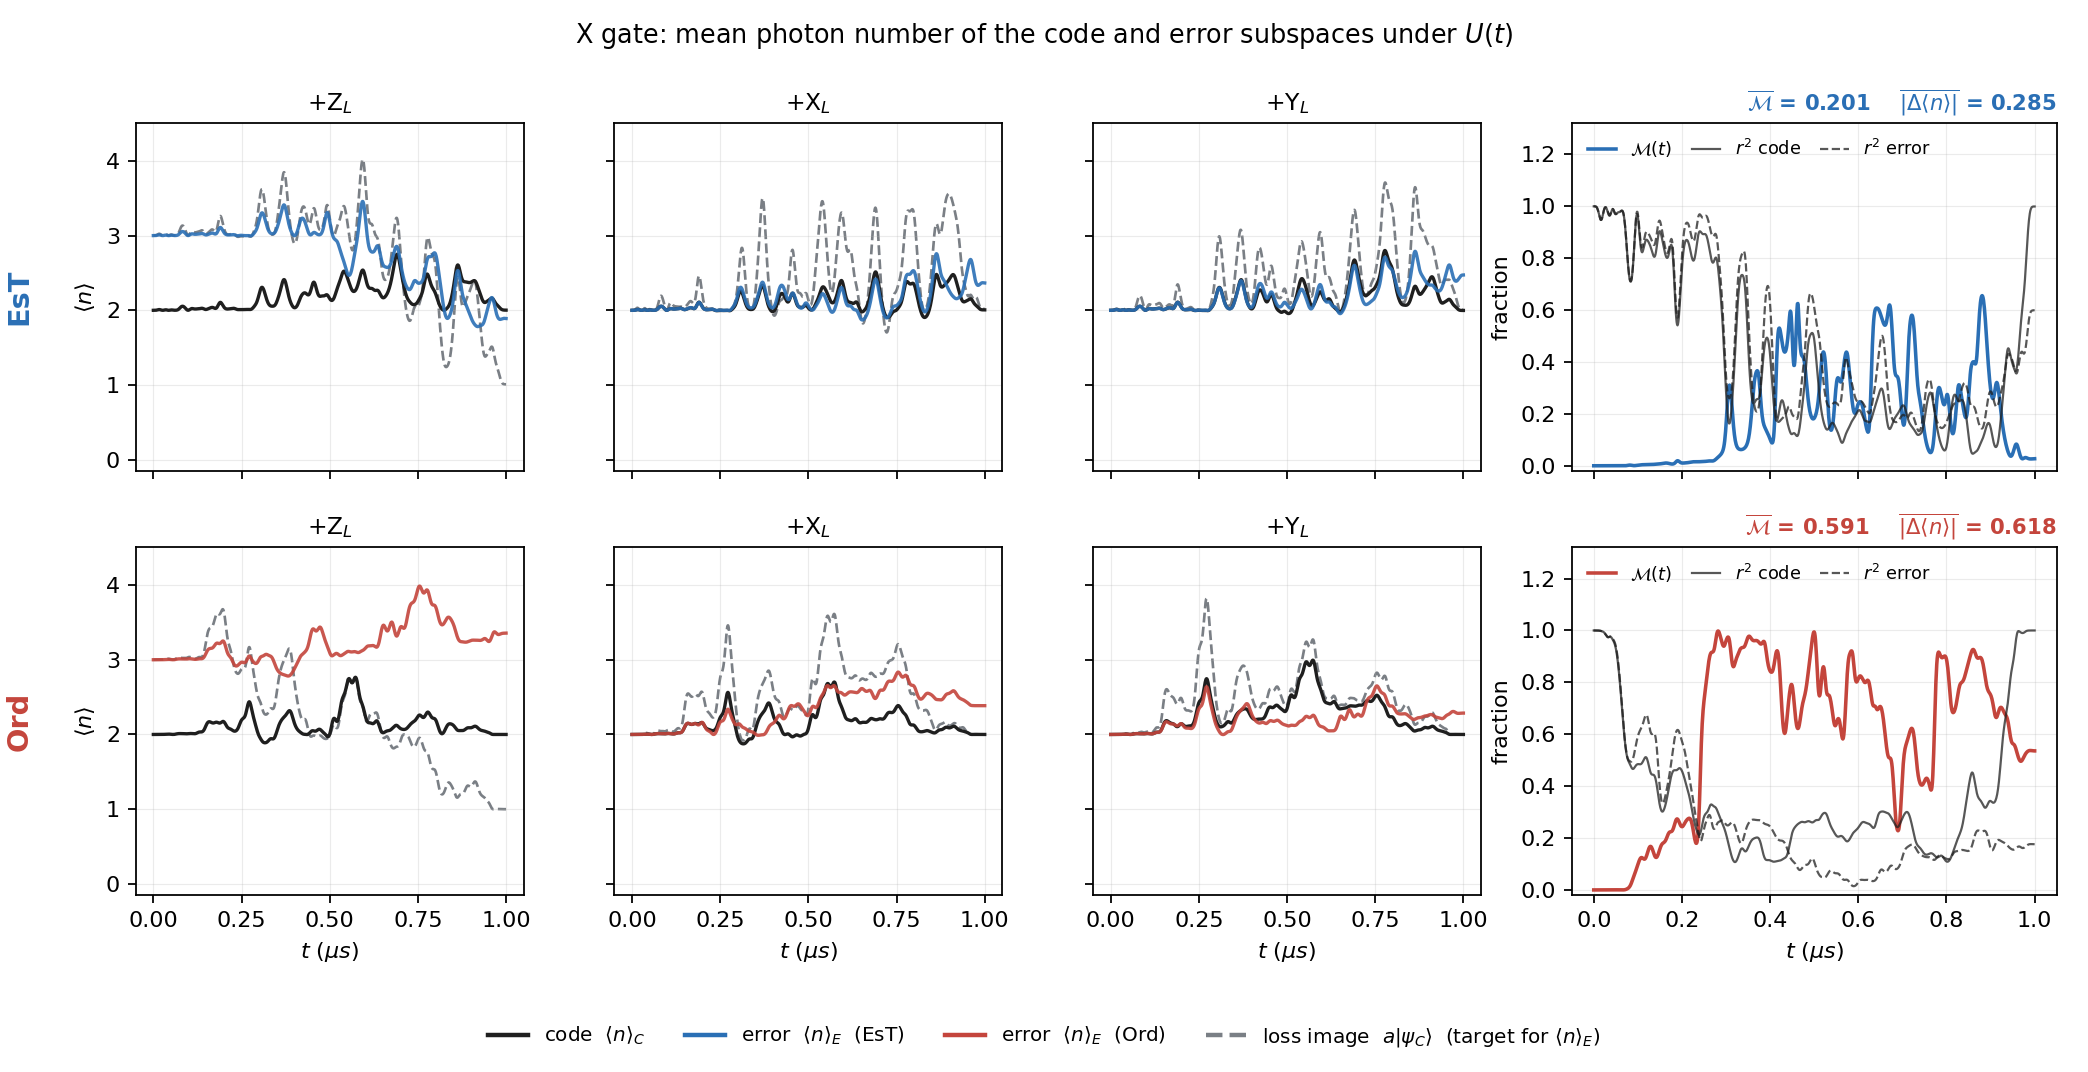

In [9]:
show(FIG1A["X"], width=900)

**Figure 1a. X gate -- mean photon number by subspace, EsT (top row) vs Ord (bottom row).**
Three Bloch cardinals per row ($+Z_L$, $+X_L$, $+Y_L$) plus the map-mismatch panel: black is
the code state, grey is the loss-image target, and colour is the error state.

**Interpretation.** In the $+Z_L$ panel the Ord error state climbs away from its target and
stays there, while the EsT error state tracks the grey curve across most of the gate. Every
code curve starts at exactly $\langle n\rangle = 2$ -- that is fixed by the code, not the
pulse, since both code words carry $\langle n\rangle = 2$ and $\langle 0_L|n|1_L\rangle = 0$
(Table 2), so no superposition of them can start anywhere else. The error cardinals do not
share that uniformity: they start split 3 / 1 / 2 / 2 / 2 / 2 over
$+Z$ / $-Z$ / $+X$ / $-X$ / $+Y$ / $-Y$, since $|0_E\rangle = |3\rangle$ and
$|1_E\rangle = |1\rangle$ carry different photon numbers.

The right-hand panel carries two supporting metrics. $\mathcal{M}(t)$ is a phase-insensitive
distance between the two **fixed**-basis blocks $U_L(t) = B^\dagger U(t) B$ and
$U_E(t) = E^\dagger U(t) E$ -- i.e., is the gate doing the *same thing* to both subspaces.
The $r^2$ curves are the surviving weight inside each fixed span; $1 - r^2$ should not be
read as leakage in the usual sense, though: $|0_L\rangle = (|0\rangle+|4\rangle)/\sqrt2$ has
its two Fock components dephase against each other under Kerr and rotate toward
$(|0\rangle-|4\rangle)/\sqrt2$, which costs weight without anything actually leaving the
$\{0,2,4\}$ sector. The error span $\{|3\rangle, |1\rangle\}$ has no internal superposition
to dephase, so it carries no such channel and stays exactly invariant under drift alone.


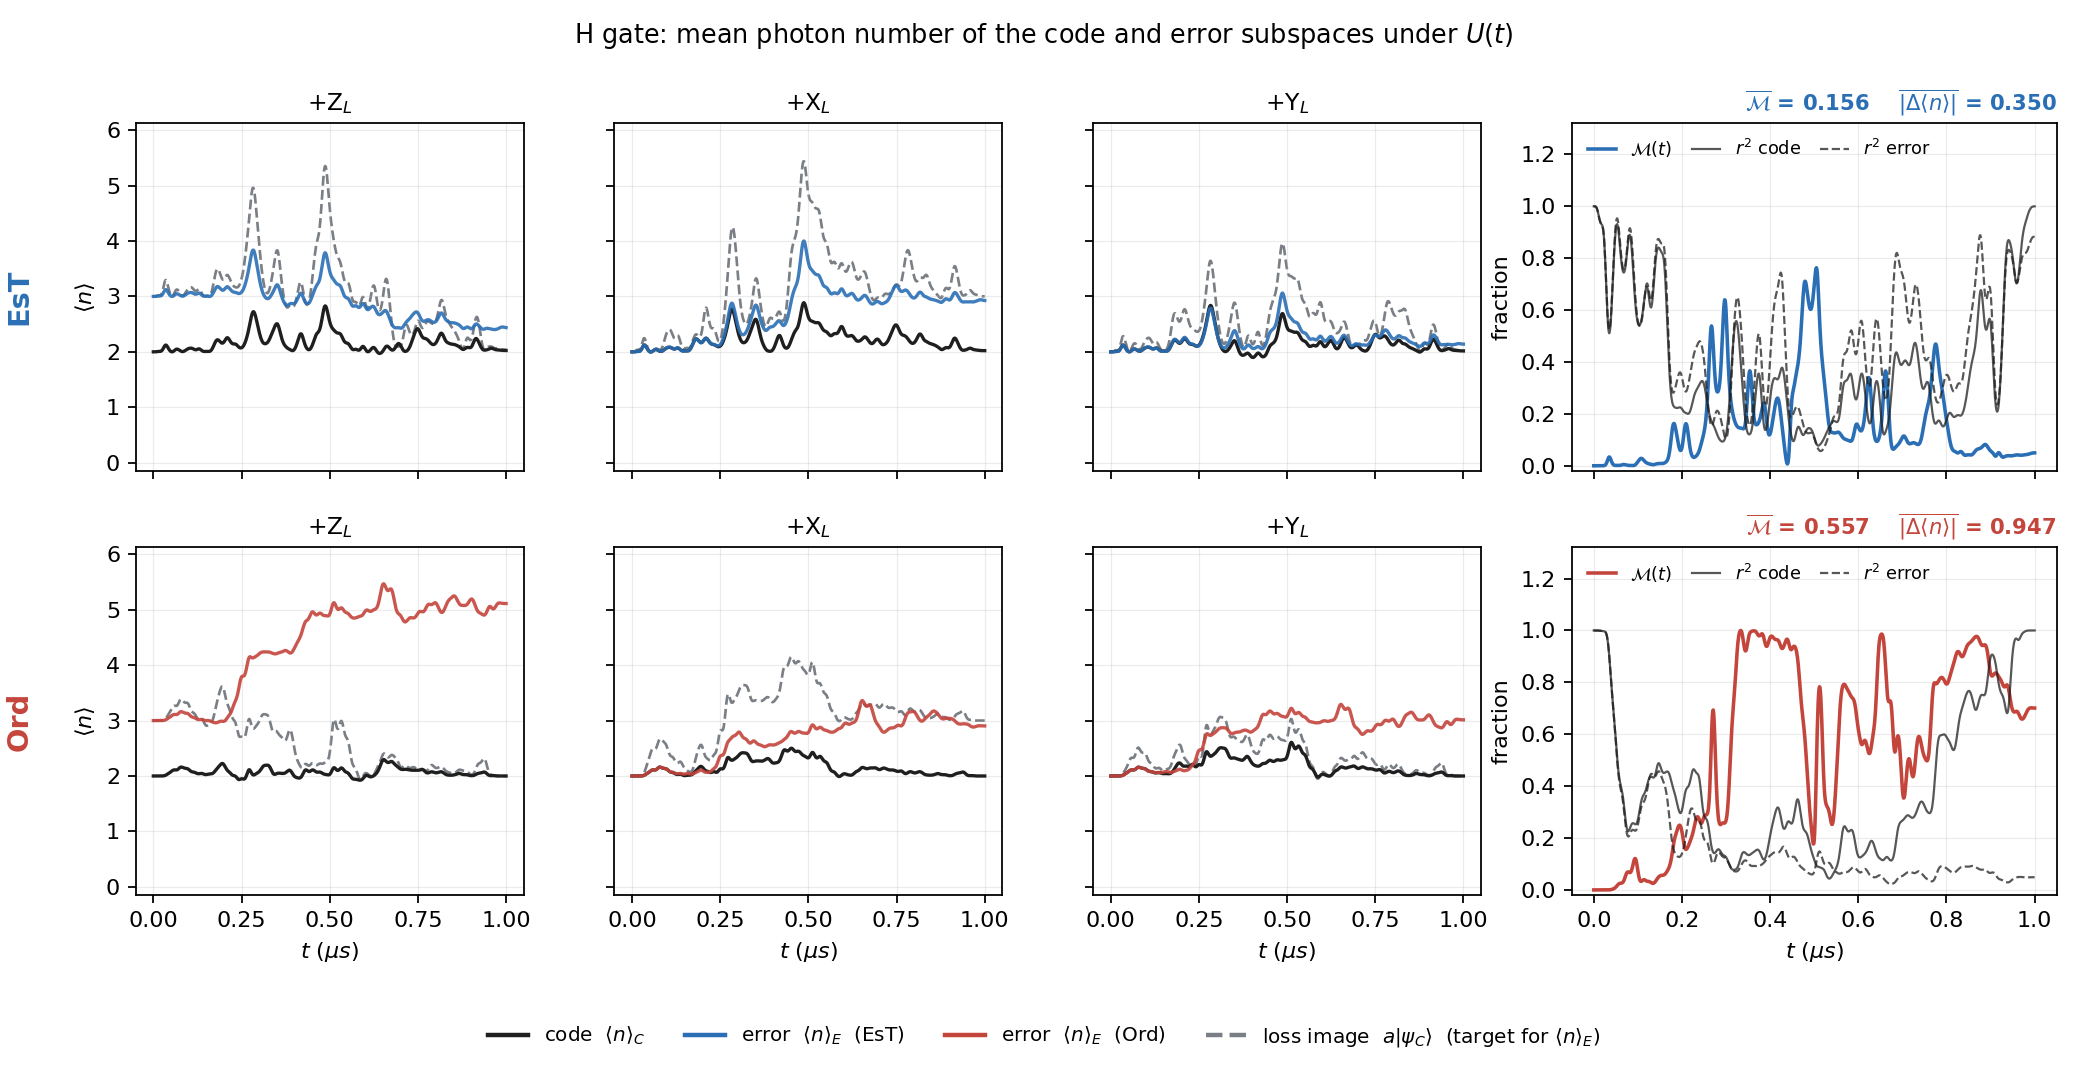

In [10]:
show(FIG1A["H"], width=900)

**Figure 1b. H gate -- same axes and cardinals as Figure 1a.** The separation is visibly
wider here: the Ord error state's excursion is larger, and the EsT error state hugs its
target more closely -- the qualitative picture behind the H-vs-X numbers in [§6.1](#6.1).


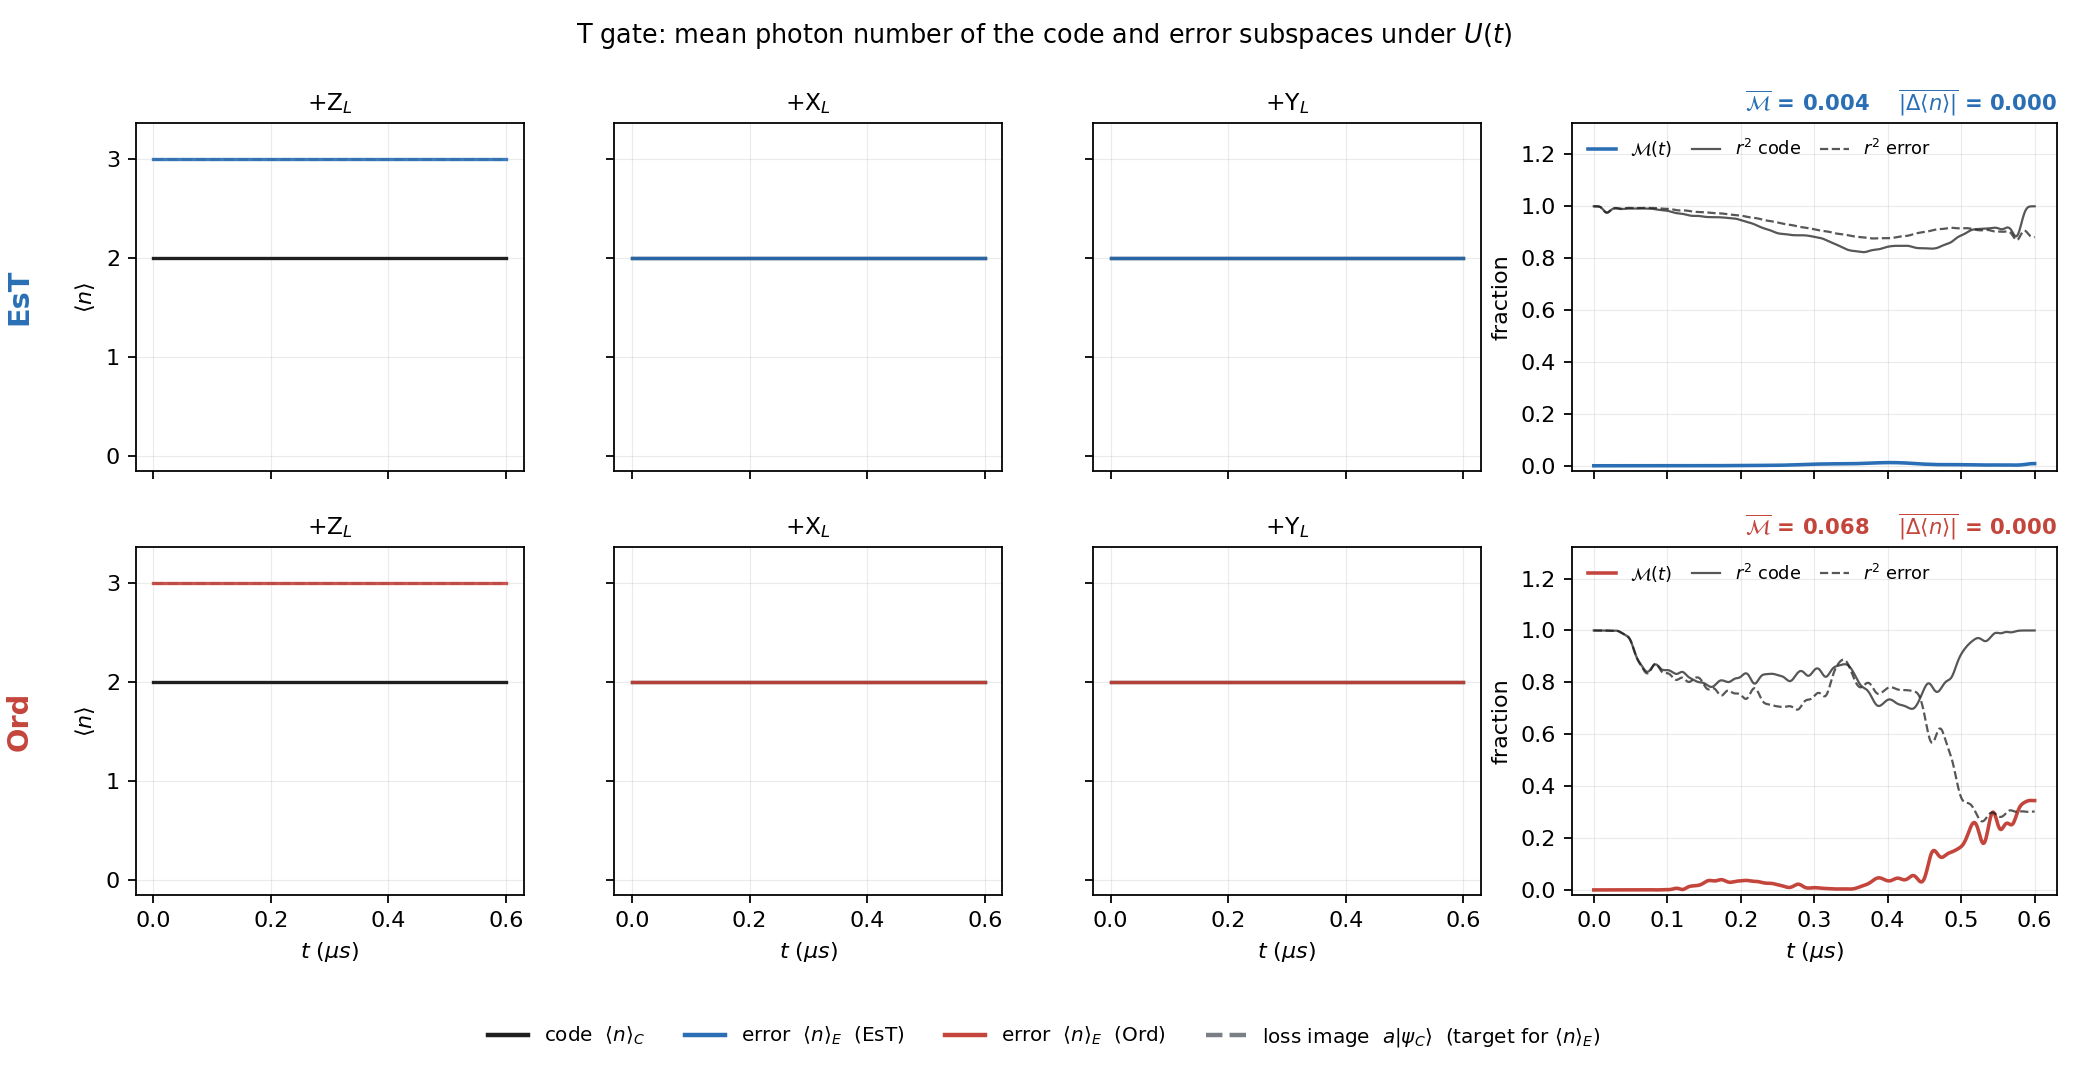

In [11]:
show(FIG1A["T"], width=900)

**Figure 1c. T gate -- same axes.** T does not drive the cavity at all (`CONTROL_MASK`), so
every code cardinal's $\langle n\rangle$ curve sits flat at exactly $2$ for *both* variants
-- there is no cavity-driven Kerr rotation to see here the way there is for X/H, since a
transmon-only drive cannot move photon number. That flatness also makes
$\overline{|\Delta\langle n\rangle_E|}$ machine-zero for T/Ord as well as T/EsT (Table 8):
this particular diagnostic is trivially satisfied by any transmon-only pulse and carries
none of the transparency signal it carries for X/H. T's transparency shows up in the
map-mismatch panel instead -- $\mathcal{M}(T)$ is $8.3\times10^{-3}$ for EsT against
$3.4\times10^{-1}$ for Ord, a 42x gap at the endpoint, wider than either X's or H's own
separation.


In [12]:
sub = pd.concat([
    pd.read_csv(os.path.join(TABLE_DIR,
        "est_fig1a_subspace" + ("" if g == "X" else f"_{g}") + ".csv"))
    for g in GATES], ignore_index=True)

KEYS = {"nbar_track_err_mean": "mean |<n>_E - <n>_loss|",
        "mismatch_mean": "mean M(t)", "mismatch_final": "M(T)",
        "nbar_err_peak": "peak <n>_E"}
view = sub[["gate", "variant"] + list(KEYS)].rename(columns=KEYS)
display(view.style.format({v: "{:.3f}" for v in KEYS.values()}).hide(axis="index"))

print("\nOrd : EsT ratios (higher = bigger EsT advantage)")
for g in GATES:
    e = sub[(sub.gate == g) & (sub.variant == "est")].iloc[0]
    o = sub[(sub.gate == g) & (sub.variant == "ord")].iloc[0]
    print(f"  {g}:  <n> tracking {o.nbar_track_err_mean / e.nbar_track_err_mean:5.2f}x    "
          f"mean M {o.mismatch_mean / e.mismatch_mean:5.2f}x    "
          f"M(T) {o.mismatch_final / e.mismatch_final:5.1f}x")

gate,variant,mean |_E - _loss|,mean M(t),M(T),peak _E
X,est,0.285,0.201,0.027,3.457
X,ord,0.618,0.591,0.536,3.986
H,est,0.350,0.156,0.050,4.000
H,ord,0.947,0.557,0.701,5.469
T,est,0.000,0.004,0.008,3.000
T,ord,0.000,0.068,0.344,3.000



Ord : EsT ratios (higher = bigger EsT advantage)
  X:  <n> tracking  2.17x    mean M  2.94x    M(T)  19.8x
  H:  <n> tracking  2.70x    mean M  3.57x    M(T)  14.1x
  T:  <n> tracking  0.63x    mean M 17.99x    M(T)  41.6x


**Table 8. Subspace-trace summary, all three gates.** $\overline{|\Delta\langle n\rangle|}$
is the time-averaged gap between the error curve and its loss-image target -- the quantity
Figure 1 plots. $\mathcal{M}$ is the map-level mismatch.

**What $\langle n\rangle$ can't show.** $H_0$ is a function of the number operators alone,
so $[H_0, n] = 0$ and $\langle n\rangle$ is *exactly* conserved under drift -- every feature
in these curves is drive-induced. That conservation also means $\langle n\rangle$ is
**blind to App. A's obstruction**: free Kerr evolution drives $\eta$ away from zero while
leaving all three photon-number curves flat, since it only rearranges phases within a fixed
photon distribution. Two states can share $\langle n\rangle$ to machine precision and still
be orthogonal. **T makes this literal, not just a caveat**: since it never drives the
cavity, $\overline{|\Delta\langle n\rangle_E|}$ sits at the floating-point floor for *both*
variants, so the `nbar_track_err_mean` ratio printed for T is noise on noise -- read
$\mathcal{M}$ for T's transparency signal instead.

So $\langle n\rangle_E = \langle n\rangle_{\mathrm{loss}}$ is **necessary for
transparency, not sufficient**. That is why the figure pairs the $\mathcal{M}$ panel with
the photon-number panels, and why the sufficient statements -- Eqs. 6--8 -- get their own
section next. The blindness above is pinned by `test_grape_jax.SubspaceEvolutionTest`.

> $\mathcal{M}$ and $\overline{|\Delta\langle n\rangle|}$ are this module's constructions,
> not the paper's printed metrics ([§2.3](#2.3), deviation 3) -- their ratios are
> meaningful, but their absolute values are not.


<a id="5"></a>
# 5. Results II -- the three transparency metrics

The paper's Eqs. 6--8, reconstructed in `EST/diagnostics.py` and evaluated on the eigh
propagator rather than the JAX one that trained the pulses:

| metric | what it tests | range |
|---|---|---|
| $\Delta_{\mathrm{QEC}}(t)$ | instantaneous Knill--Laflamme validity of the *evolved* code space for the error set $\{I, a\}$ | $\ge 0$, normalization chosen |
| $L_{E_j}(t)$ | how much of the evolved error state has left the *instantaneous* error space | $[0,1]$ |
| $\eta_{E_j,\psi}(t)$ | mismatch between the evolved error state and the photon-loss image of the evolved code state | $[0,1]$ |

$L \le \eta$ is expected -- leaving the error space is one way to mismatch the target, not the
only one -- and is observed. $\eta$ is *exactly* the time-resolved integrand of $C_2$, so
$\mathrm{mean}(\eta) \equiv 1 - F_{\mathrm{ET}}$; that identity is checked across the two code
paths in [§7](#7).

In [13]:
if REGENERATE_FIGURES:
    for g in GATES:
        diagnostics.main(gate=g, scale="both")
else:
    print("REGENERATE_FIGURES=False -- using the figures already on disk")

FIG1DEF = {g: os.path.join(FIG_DIR, "fig1def_est_vs_ord"
                           + ("" if g == "X" else f"_{g}") + "_linear.png") for g in GATES}


=== X / est ===
  C1 fidelity (eigh re-score, n_c=20) : 0.999285
  per-cardinal                        : 0.9995 0.9991 0.9993 0.9993 0.9993 0.9993
  max active Fock level (>1% pop)     : 9
  truncation scan                     : n_c=16:0.99928  n_c=18:0.99929  n_c=20:0.99929  n_c=22:0.99929  n_c=24:0.99929  n_c=28:0.99929
  truncation spread                   : 8.03e-06   OK
  time-averaged Delta_QEC / L / eta    : 3.5790e-02  1.4800e-01  2.6996e-01

=== X / ord ===
  C1 fidelity (eigh re-score, n_c=20) : 0.999999
  per-cardinal                        : 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000
  max active Fock level (>1% pop)     : 8
  truncation scan                     : n_c=16:1.00000  n_c=18:1.00000  n_c=20:1.00000  n_c=22:1.00000  n_c=24:1.00000  n_c=28:1.00000
  truncation spread                   : 1.29e-09   OK
  time-averaged Delta_QEC / L / eta    : 6.9200e-02  4.6618e-01  8.0596e-01

--- EsT vs Ord (time-averaged, lower is better) ---
  delta_qec   EsT=3.5790e-02  Ord=6.9

The cell above also wrote the log-axis versions (`fig1def_est_vs_ord[_H][_T].png`), which are
the paper's own view. The **linear** axes are shown below instead: these metrics sit at
$O(0.1)$, where a log axis exaggerates the separation by compressing the region the curves
actually occupy.

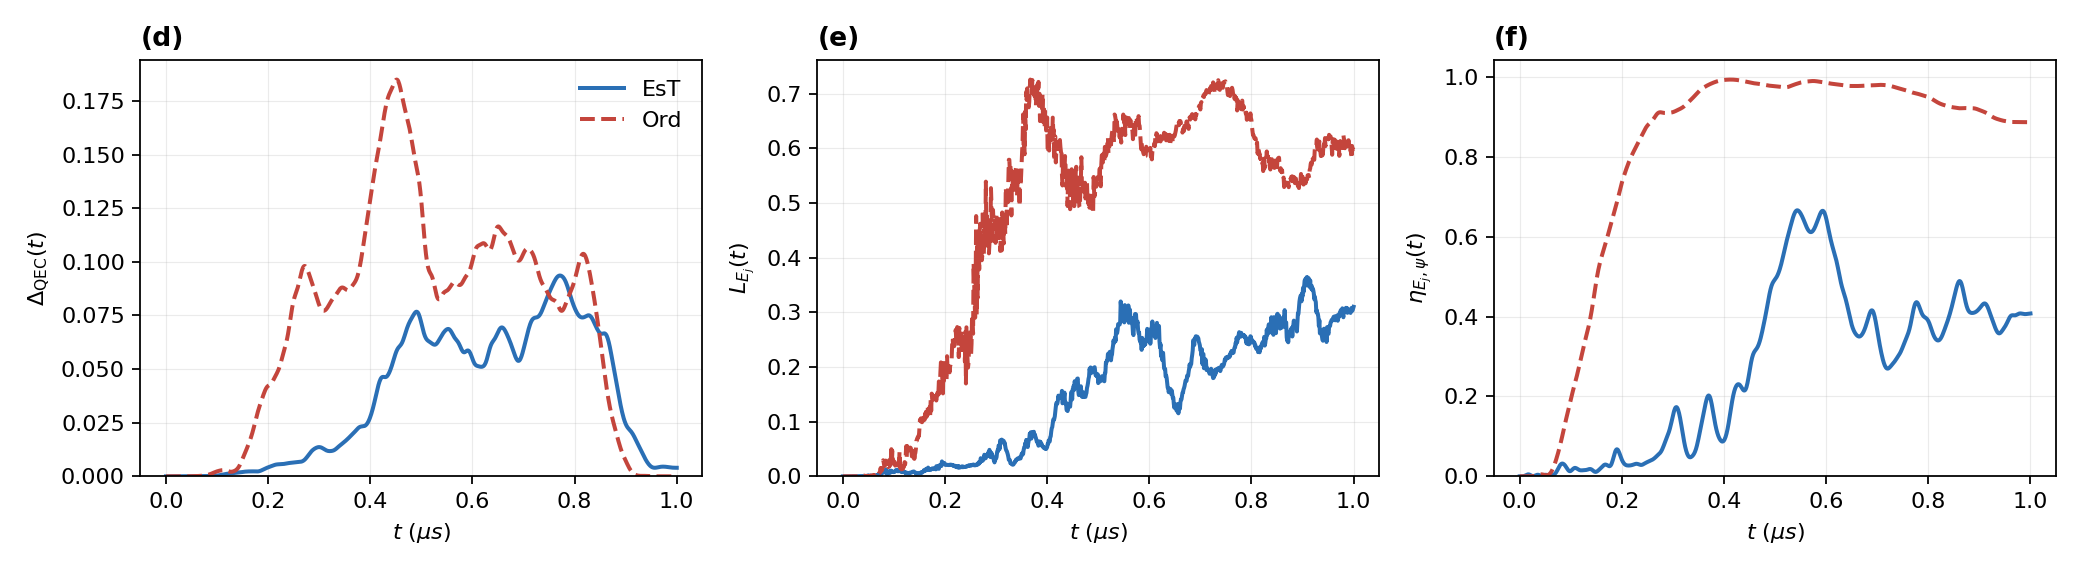

In [14]:
show(FIG1DEF["X"], width=900)

**Figure 2a. X gate -- $\Delta_{\mathrm{QEC}}$, $L_{E_j}$, $\eta_{E_j,\psi}$ against time, EsT
(blue) vs Ord (red dashed), linear axes.** Both pulses are 1.0 us; curves are averaged over the
six cardinals.

**Interpretation.** EsT sits below Ord across the whole gate on $L$ and $\eta$, by roughly a
factor of three, and the curves flatten rather than descending to zero -- that floor is App. A
([§1.3](#1.3)) and is expected.

**The $\Delta_{\mathrm{QEC}}$ endpoint is an artifact, not a result.** The Ord curve dives below
EsT in the last moments of the gate, purely because Ord's terminal fidelity is higher: a gate
that lands exactly on the ideal code words has zero Knill--Laflamme violation by construction,
whatever it did on the way. Read this panel mid-gate, where transparency is the property at
issue and the time-average has EsT ahead by 1.93x (Table 9).

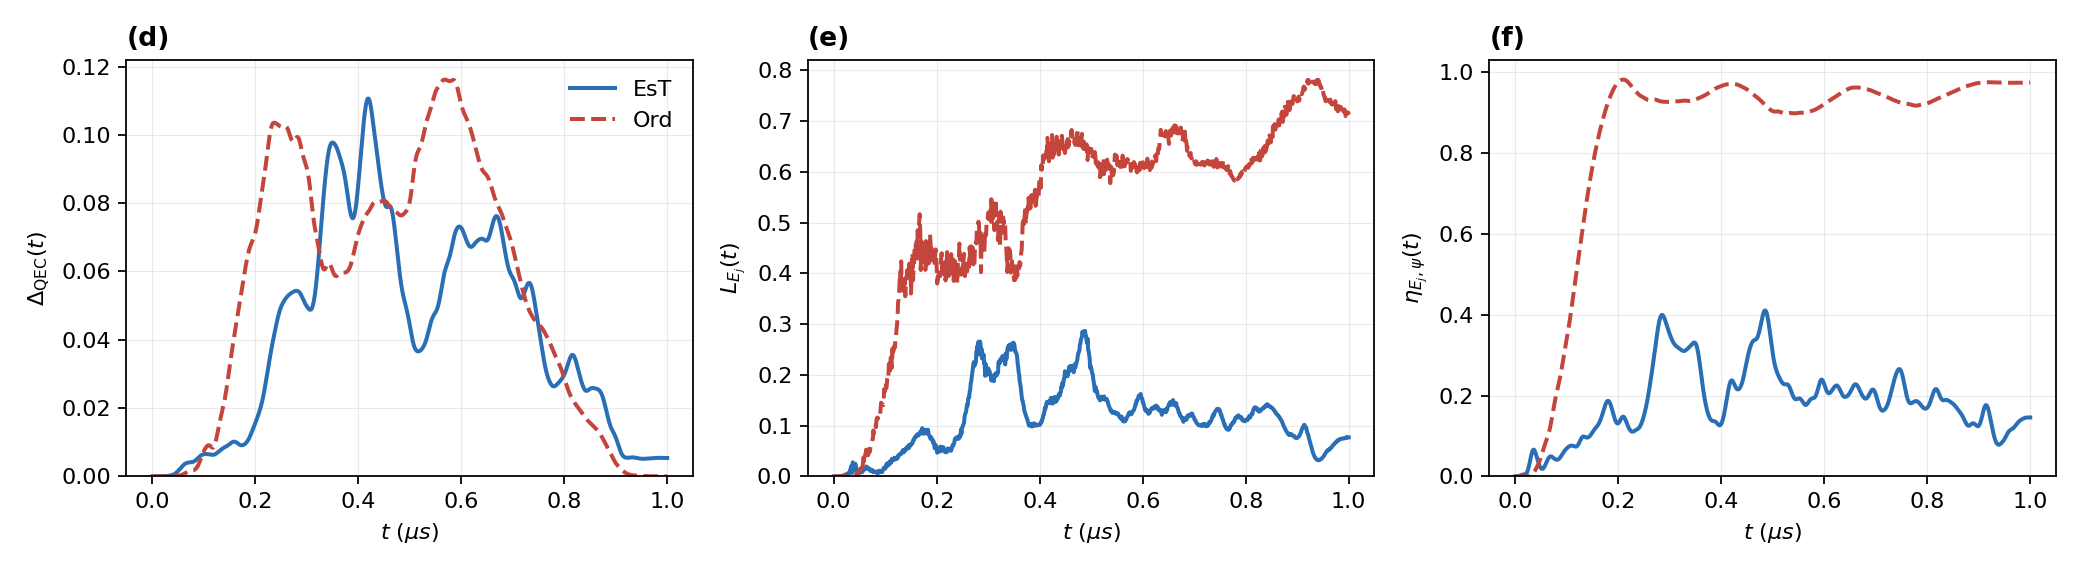

In [15]:
show(FIG1DEF["H"], width=900)

**Figure 2b. H gate -- same axes.** The $L$ and $\eta$ panels separate further than Figure 2a's,
and the EsT curves are flatter: the H pulse holds its transparency more evenly across the gate
rather than degrading toward the end.

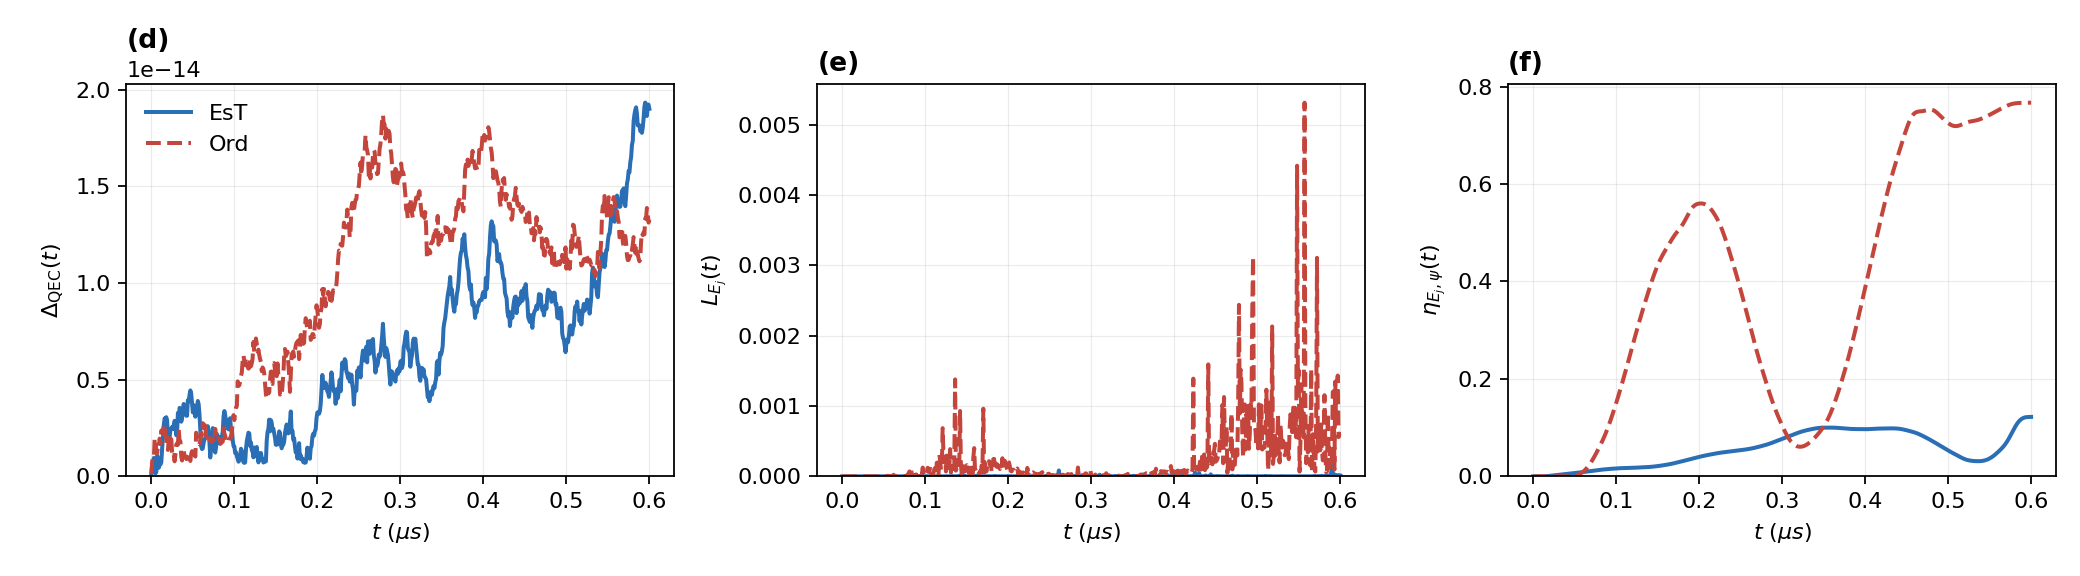

In [16]:
show(FIG1DEF["T"], width=900)

**Figure 2c. T gate -- same axes.** Both curves sit far below X/H's: T/EsT's $\eta$ and $L$
traces are almost flat near zero, and even T/Ord -- which never touches $C_2$ or $C_3$ -- stays
under H/Ord's peak. This is the flip side of Table 6's near-instant `ord` convergence: a
diagonal phase gate has much less room to scramble the error space against the code space in
the first place, so both variants start from a more transparent baseline than X or H's `ord`
ever reaches. The 80.97x ($L$) and 7.12x ($\eta$) EsT:Ord gaps in Table 9 are real, but they are
gaps between two *easy* baselines, not gaps at the same absolute difficulty as X/H's -- see
[§6.1](#6.1).

In [17]:
met = pd.concat([
    pd.read_csv(os.path.join(TABLE_DIR,
        "est_fig1_metrics" + ("" if g == "X" else f"_{g}") + ".csv"))
    for g in GATES], ignore_index=True)

# F_ET is the JAX training value; mean(eta) is its eigh-path twin (see section 7).
met["F_ET"] = 1.0 - met["eta_mean"]
view = met[["gate", "variant", "F1", "F_ET", "delta_qec_mean", "leakage_mean",
            "eta_mean", "max_active_fock", "trunc_spread"]]
display(view.style.format({"F1": "{:.6f}", "F_ET": "{:.4f}", "delta_qec_mean": "{:.4f}",
                           "leakage_mean": "{:.4f}", "eta_mean": "{:.4f}",
                           "trunc_spread": "{:.2e}"}).hide(axis="index"))

print("\nOrd : EsT ratios (higher = bigger EsT advantage)")
ratio_rows = []
for g in GATES:
    e = met[(met.gate == g) & (met.variant == "est")].iloc[0]
    o = met[(met.gate == g) & (met.variant == "ord")].iloc[0]
    ratio_rows.append({"gate": g,
                       "F1 EsT": e.F1, "F1 Ord": o.F1,
                       "infidelity cost": (1 - e.F1) - (1 - o.F1),
                       "Delta_QEC": o.delta_qec_mean / e.delta_qec_mean,
                       "L": o.leakage_mean / e.leakage_mean,
                       "eta": o.eta_mean / e.eta_mean,
                       "F_ET EsT/Ord": (1 - e.eta_mean) / (1 - o.eta_mean)})
display(pd.DataFrame(ratio_rows).style.format(
    {"F1 EsT": "{:.6f}", "F1 Ord": "{:.6f}", "infidelity cost": "{:.2e}",
     "Delta_QEC": "{:.2f}x", "L": "{:.2f}x", "eta": "{:.2f}x",
     "F_ET EsT/Ord": "{:.2f}x"}).hide(axis="index"))

gate,variant,F1,F_ET,delta_qec_mean,leakage_mean,eta_mean,max_active_fock,trunc_spread
X,est,0.999285,0.7300,0.0358,0.1480,0.2700,9,8.03e-06
X,ord,0.999999,0.1940,0.0692,0.4662,0.8060,8,1.29e-09
H,est,0.999675,0.8175,0.0408,0.1134,0.1825,10,6.88e-07
H,ord,0.999999,0.1646,0.0531,0.5278,0.8354,8,9.70e-09
T,est,0.999982,0.9452,0.0000,0.0000,0.0548,4,7.48e-14
T,ord,1.000000,0.6100,0.0000,0.0002,0.3900,4,2.79e-14



Ord : EsT ratios (higher = bigger EsT advantage)


gate,F1 EsT,F1 Ord,infidelity cost,Delta_QEC,L,eta,F_ET EsT/Ord
X,0.999285,0.999999,7.14e-04,1.93x,3.15x,2.99x,3.76x
H,0.999675,0.999999,3.23e-04,1.30x,4.65x,4.58x,4.97x
T,0.999982,1.000000,1.83e-05,1.57x,80.97x,7.12x,1.55x


**Table 9. Headline metrics for all six pulses, plus the EsT:Ord ratios.** Time-averaged over
the gate and over the six cardinals; lower is better except for the two fidelities.

Four readings.

**The fidelity cost of transparency is small and real, and smallest for T.** EsT gives up
$7\times10^{-4}$ (X), $3\times10^{-4}$ (H), and $1.8\times10^{-5}$ (T) of ordinary fidelity
against a control that reaches $\sim 1.000000$ in every case. That is the intended trade, not a
defect: `ord` optimizes $C_1$ alone and drives it as far as L-BFGS-B can, while `est` spends part
of the same budget on $C_2$ and $C_3$.

**On X and H, transparency buys a factor of 3--4.6 on the error-space metrics**, consistently
across $L$, $\eta$, and $F_{\mathrm{ET}}$. $\Delta_{\mathrm{QEC}}$ moves less (1.3--1.9x), partly
for the endpoint reason above.

**T's ratios are an order of magnitude larger -- 80.97x on $L$, 7.12x on $\eta$ -- and are not
the same kind of number.** T/Ord is close to opaque by construction ($\eta \approx 0.39$, still
well under X/H's own `ord` values) simply because nothing in its objective discourages
scrambling the error space, while T/EsT pushes $\eta$ down to $0.055$ on a gate with an order of
magnitude less room to go wrong in the first place (max active Fock level 4, against 8--10 for
X/H). Read the size of the ratio as a property of how permissive T's `ord` baseline is, not as
T's EsT pulse being several times better-behaved than H's.

**H beats X on every error-space metric at higher $F_1$; T is not part of that comparison.**
X-vs-H is a controlled, same-$N$, same-schedule comparison; T runs a shorter gate ($N=600$
against $1000$) with a transmon-only drive, so it is not commensurable with either -- see
[§6.1](#6.1).

> Ratios are the result; absolute values inherit `diagnostics.py`'s normalization choices
> ([§2.3](#2.3)). `max_active_fock` differs between X/H's two variants -- see [§9](#9),
> limitation 2 -- but *matches* for T's two variants (4 and 4), so T is, unusually, the one gate
> here where the fair-comparison criterion is actually satisfied.

<a id="6"></a>
# 6. Results III -- the delivered waveforms

Nothing in `EST/` plots a trained pulse, and `visualization/pulse_viz.plot_pulse_waveforms` is
not reusable here: it is hardcoded to the main pipeline's MHz units and `dt = 0.002`, plots one
pulse per figure, and has no amplitude-cap line or EsT/Ord overlay. The helper below is local to
this notebook.

It plots the **quadrature-pair magnitude** $|\varepsilon| = \sqrt{I^2 + Q^2}$, because that is
the quantity $C_4$ caps -- not $I$ and $Q$ separately.

In [18]:
def plot_est_waveforms(u_est, u_ord, gate, dt=device.DT, save_path=None):
    """|eps| against the C4 cap for both variants, plus the EsT I/Q traces underneath."""
    N = u_est.shape[0]
    t_ns = np.arange(N) * dt * 1e3
    T_ns = N * dt * 1e3
    # The ramp profile, scaled to the cap for visibility. NOT a ceiling: the envelope
    # multiplies the raw pre-image, which is not itself capped, so |eps| can exceed it.
    envelope = device.ramp_envelope(N, dt) * device.EPS_MAX

    fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
    for row, (lo, name) in enumerate(((0, "cavity"), (2, "transmon"))):
        ax = axes[row, 0]
        ax.plot(t_ns, np.hypot(u_est[:, lo], u_est[:, lo + 1]), color=EST_COLOR, lw=0.9, label="EsT")
        ax.plot(t_ns, np.hypot(u_ord[:, lo], u_ord[:, lo + 1]), color=ORD_COLOR, lw=0.8,
                ls="--", label="Ord")
        ax.plot(t_ns, envelope, color="0.45", lw=0.9, ls=":", label="ramp envelope (scaled)")
        ax.axhline(device.EPS_MAX, color="0.15", lw=0.9)
        for x0, x1 in ((0.0, device.RAMP_NS), (T_ns - device.RAMP_NS, T_ns)):
            ax.axvspan(x0, x1, color="0.88", zorder=0)
        ax.set_ylabel(f"|eps_{name[0].upper()}|  (rad/us)")
        ax.set_ylim(0, device.EPS_MAX * 1.18)
        ax.grid(alpha=0.25)
        if row == 0:
            ax.legend(loc="lower center", ncol=3, fontsize=8, framealpha=0.9)
            ax.set_title(f"drive magnitude vs the C4 cap  ({gate} gate)", fontsize=10)

        ax2 = axes[row, 1]
        ax2.plot(t_ns, u_est[:, lo], color=EST_COLOR, lw=0.7, label="I")
        ax2.plot(t_ns, u_est[:, lo + 1], color="#8a5fb0", lw=0.7, label="Q")
        ax2.axhline(0, color="0.6", lw=0.6)
        ax2.set_ylabel(f"{name} I / Q  (rad/us)")
        ax2.grid(alpha=0.25)
        if row == 0:
            ax2.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)
            ax2.set_title("EsT quadratures", fontsize=10)
    for ax in axes[1]:
        ax.set_xlabel("t (ns)")
    fig.suptitle(f"{gate} gate -- delivered waveforms   "
                 f"(shaded: {device.RAMP_NS:.0f} ns ramp windows)", fontsize=11)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
        print(f"saved -> {save_path}")
    plt.close(fig)
    return save_path

FIG3 = {}
for g in GATES:
    FIG3[g] = plot_est_waveforms(PULSES[(g, "est")], PULSES[(g, "ord")], g,
                                 save_path=os.path.join(FIG_DIR, f"fig3_waveforms_{g}.png"))

saved -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig3_waveforms_X.png
saved -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig3_waveforms_H.png
saved -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig3_waveforms_T.png


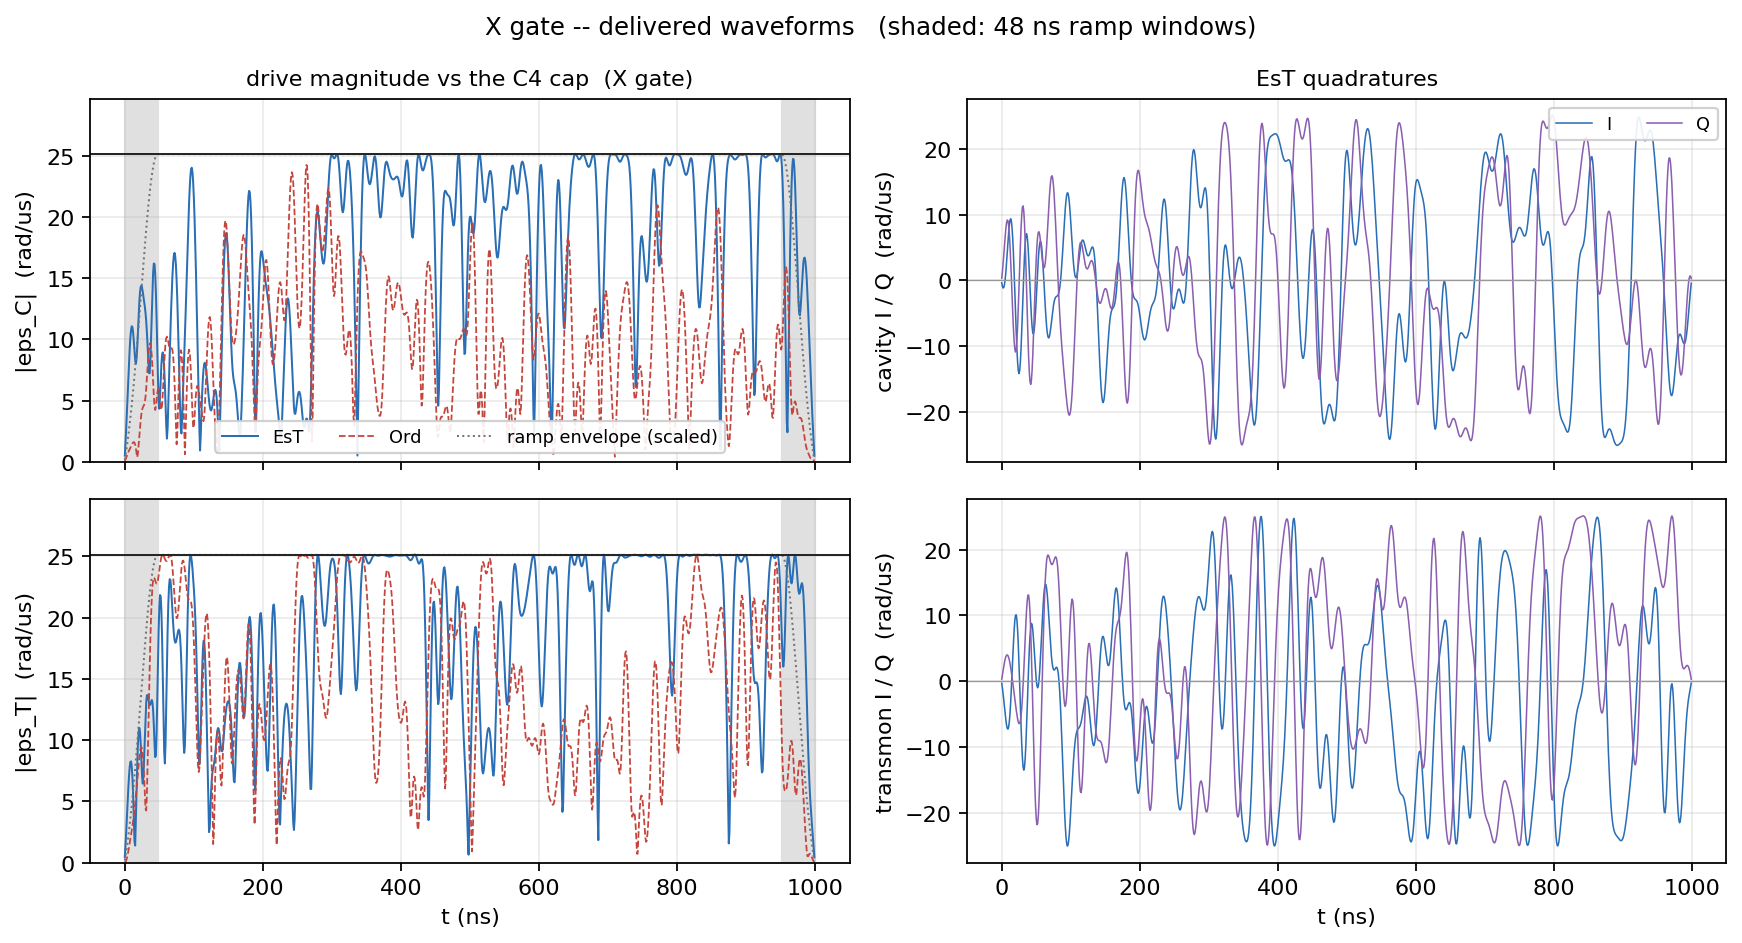

In [19]:
show(FIG3["X"], width=880)

**Figure 3a. X gate -- delivered waveforms.** Left column: quadrature-pair magnitude for EsT
(blue) and Ord (red dashed) against the $C_4$ cap (solid black), with the ramp envelope scaled
to the cap for reference (dotted grey). Right column: the EsT pulse's underlying $I$ and $Q$. Shading
marks the 48 ns ramp windows.

**The cap binds for EsT and not for Ord.** The blue trace saturates $\varepsilon_{\max}$
repeatedly on both drives -- a bang-bang-flavoured solution, not a smooth one -- while the red
Ord trace, especially on the cavity, spends most of the gate well below it. Ord reaches its
$F_1 \approx 1$ without needing the full amplitude budget; EsT needs all of it and then some,
which is the same fact as its 0.2% $C_4$ overshoot in Table 7. This is also why the amplitude
limit has to be $C_4$ and not the L-BFGS-B box ([§2.4](#2.4)): the box constrains the raw
pre-image, and the quantity actually pinned at 25.13 here is a *derived* circular magnitude.

**The dotted curve is the ramp profile, not a bound.** The constraint chain multiplies the
envelope into the pre-image, and the pre-image is not itself capped, so $|\varepsilon|$ can and
does exceed `ramp x eps_max` inside the shaded windows. What the envelope does guarantee is the
taper -- both variants go to zero at both ends rather than switching on abruptly.

**EsT and Ord are different waveforms, not perturbations of each other.** The magnitude traces
agree nowhere in detail, consistent with the two objectives landing in different optimizer
basins rather than $C_2$ and $C_3$ nudging the Ord solution. Table 7's systematic differences
-- 10x the transmon out-of-band energy, 8x the endpoint/mid ratio -- are the quantitative form
of the same observation.

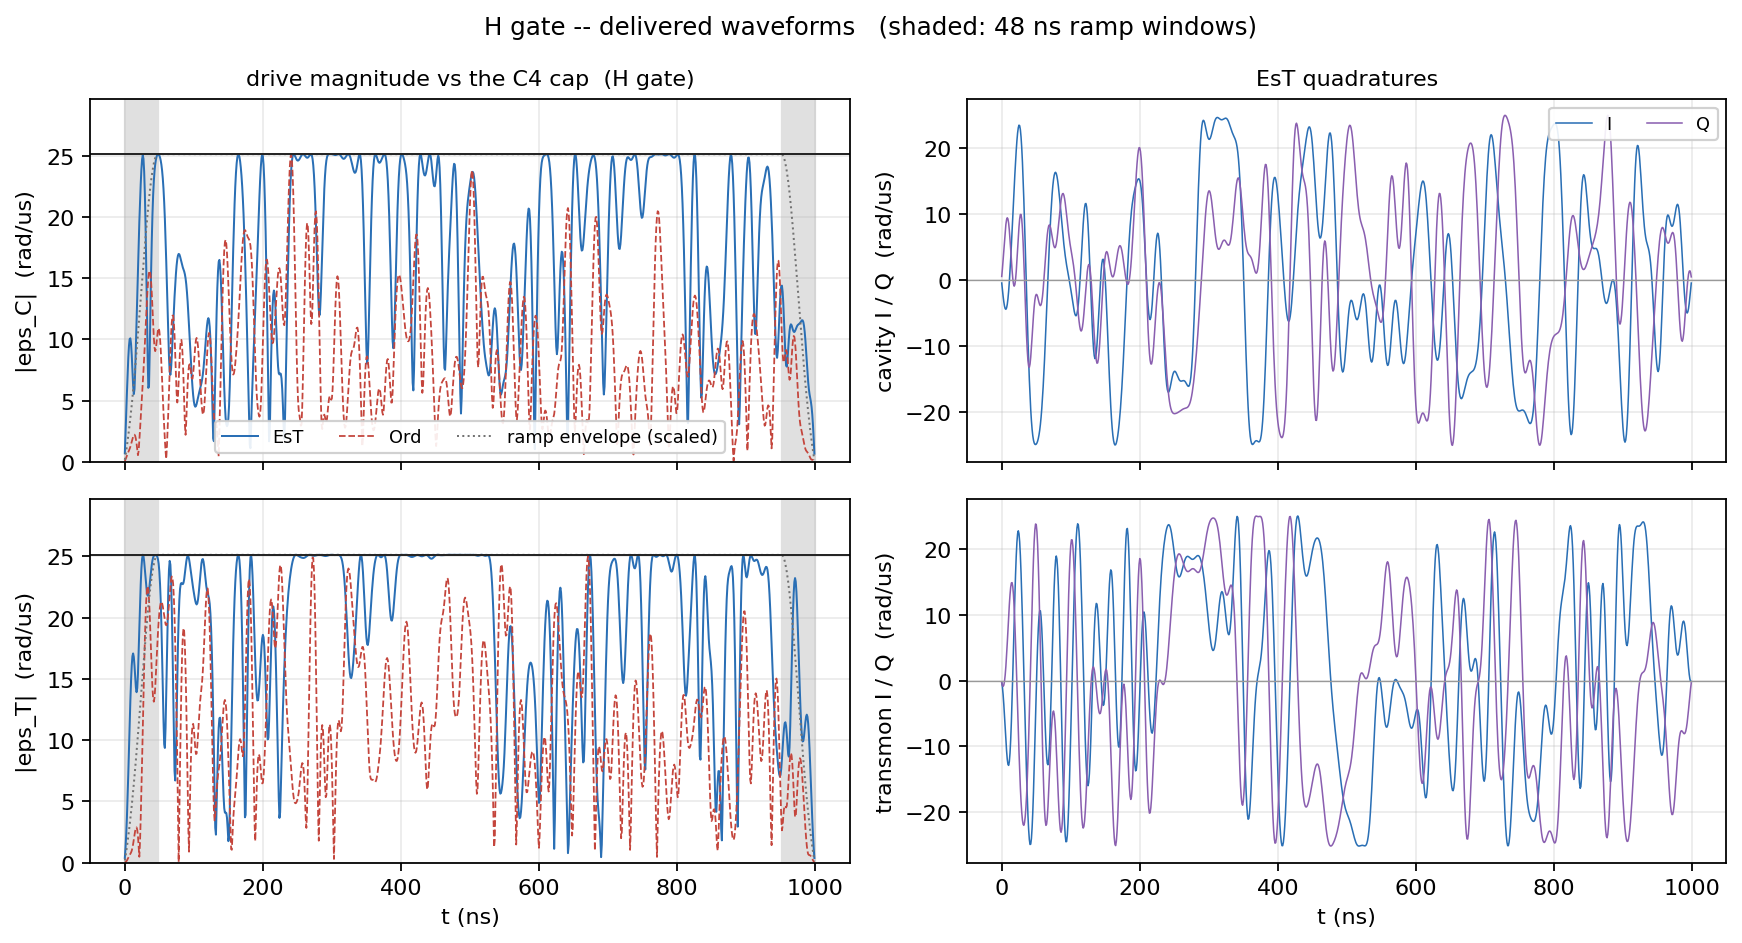

In [20]:
show(FIG3["H"], width=880)

**Figure 3b. H gate -- same axes.** Structurally the same picture, slightly more pronounced: the
EsT cavity drive reaches the cap inside the opening ramp window, within the first 30 ns, and
holds it through long stretches of the gate. The H pulses work against the *same*
$\varepsilon_{\max}$, the same $N$, and the same band as X, so the H-vs-X difference in
[§6.1](#6.1) is not a matter of one gate being allowed to drive harder.

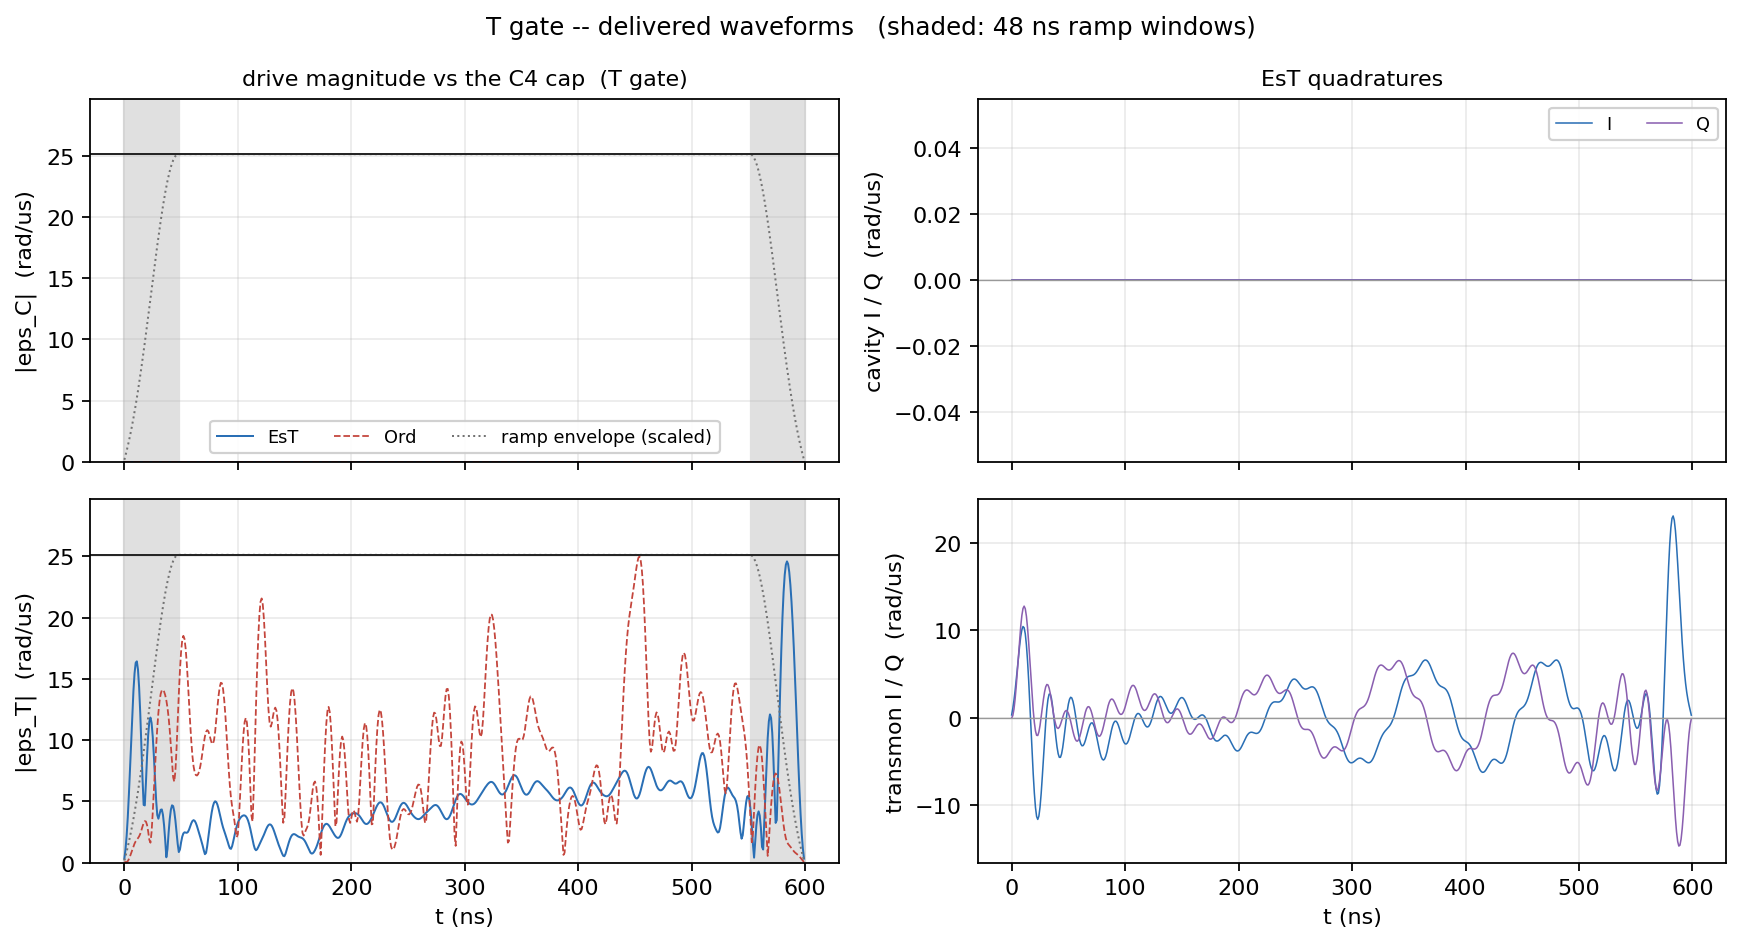

In [21]:
show(FIG3["T"], width=880)

**Figure 3c. T gate -- delivered waveforms.** The cavity panels (top row) are exactly zero for
both variants -- not approximately, exactly, since `CONTROL_MASK` multiplies those two columns
by 0 -- which is the clearest possible confirmation that the transmon-only constraint from
[§1.2](#1.2) is doing its job. All of the action is in the bottom row. `ord` converges to a
small, smooth pulse well inside the cap in 16 iterations (Table 6); `est` drives much harder and
noticeably closer to $\varepsilon_{\max}$, and -- as Table 7 shows -- puts more of that drive
into the ramp windows than X or H's `est` pulses do, which is visible here as amplitude that
does not taper as cleanly toward the shaded edges.

<a id="6.1"></a>
### 6.1 Cross-gate synthesis: the H-vs-X gap, and what the second stage does

In [22]:
rows = []
for g in GATES:
    info = RUNS[(g, "est")]
    nc = str(info["trunc_list"][0])
    for st in info["stages"]:
        t = st["terms"][nc]
        rows.append({"gate": g, "after stage": st["stage"],
                     "F1": 1 - t["c1"], "infidelity": t["c1"],
                     "F_ET": 1 - t["c2"], "C3 (vel. var.)": t["c3"]})
stage = pd.DataFrame(rows)
display(stage.style.format({"F1": "{:.5f}", "infidelity": "{:.2e}",
                            "F_ET": "{:.4f}", "C3 (vel. var.)": "{:.5f}"}).hide(axis="index"))

for g in GATES:
    s1 = stage[(stage.gate == g) & (stage["after stage"] == 1)].iloc[0]
    s2 = stage[(stage.gate == g) & (stage["after stage"] == 2)].iloc[0]
    ord_c3 = RUNS[(g, "ord")]["stages"][-1]["terms"][str(RUNS[(g, "ord")]["trunc_list"][0])]["c3"]
    print(f"{g}:  stage 2 improves infidelity {s1.infidelity/s2.infidelity:5.0f}x, "
          f"moves F_ET by {100*(s2.F_ET-s1.F_ET)/s1.F_ET:+5.1f}%, "
          f"and regresses C3 {s2['C3 (vel. var.)']/s1['C3 (vel. var.)']:5.1f}x "
          f"(Ord sits at {ord_c3:.4f})")

gate,after stage,F1,infidelity,F_ET,C3 (vel. var.)
X,1,0.95706,4.29e-02,0.7290,0.00949
X,2,0.99929,7.15e-04,0.7300,0.14772
H,1,0.96112,3.89e-02,0.8268,0.00630
H,2,0.99968,3.25e-04,0.8175,0.12585
T,1,0.97331,2.67e-02,0.9154,0.01038
T,2,0.99998,1.83e-05,0.9452,0.20231


X:  stage 2 improves infidelity    60x, moves F_ET by  +0.1%, and regresses C3  15.6x (Ord sits at 0.1197)
H:  stage 2 improves infidelity   120x, moves F_ET by  -1.1%, and regresses C3  20.0x (Ord sits at 0.1233)
T:  stage 2 improves infidelity  1456x, moves F_ET by  +3.3%, and regresses C3  19.5x (Ord sits at 0.1536)


**Table 10. Stage decomposition of the two EsT runs.** Stage 1 buys transparency with fidelity
exactly as designed: $F_1$ falls to $\sim 0.96$ while $F_{\mathrm{ET}}$ climbs and velocity
variance drops by an order of magnitude. Stage 2 then recovers 60x (X) and 120x (H) in
infidelity for almost nothing: X's $F_{\mathrm{ET}}$ actually improves by 0.1% across the
stage, and H's gives up 1.1%.

**A documentation defect, worth recording.** `train_est.py`'s docstring says stage 2 moves the
ET *and velocity* metrics by ~1%. That holds for $F_{\mathrm{ET}}$ and not for $C_3$, which
regresses by more than an order of magnitude straight back to the Ord level -- because $w_3 = 0$
in stage 2 and nothing then holds the trajectory speed uniform. **Velocity uniformity is not a
property of the delivered pulse; it is scaffolding stage 1 uses to stop the optimizer parking
the dynamics to cheat $C_2$** ([§2.1](#2.1)).

**The H-vs-X gap.** At an identical 2000-it/stage cold start, with identical per-iteration cost
($N$, $n_t$, $n_c$ all equal; only the target unitary differs), H reaches $F_{\mathrm{ET}} =
0.818$ against X's 0.730 and beats X on every error-space metric in Table 9 *at higher* $F_1$.
The Ord baselines are comparable across the two gates ($L = 0.528$ for H against 0.466 for X),
so the difference lives in the EsT pulse rather than in a shifted control. The single exception
is $\Delta_{\mathrm{QEC}}$, where X leads -- so whatever favours H does not favour it uniformly.

Iteration count was the obvious explanation and has been ruled out ([§9](#9), limitation 1).
**The gap is gate-dependent, and its cause is not yet identified.**

**T, for reference, not comparison.** T's own stage decomposition is far more extreme than
either: stage 1 already reaches $F_{\mathrm{ET}} = 0.915$ (against a start of $0.600$), and
stage 2 buys a **1456x** infidelity improvement ($2.67\times10^{-2} \to 1.83\times10^{-5}$)
while $F_{\mathrm{ET}}$ *improves* a further 3.3% rather than giving anything back -- neither X
nor H's stage 2 gains transparency, they only lose a little or a lot. T's $C_3$ also regresses
past its own `ord` baseline in stage 2 ($0.202$ against `ord`'s $0.154$), unlike X and H whose
stage-2 $C_3$ lands close to *at or under* their own `ord` level. None of this is directly
comparable to the H-vs-X numbers above -- different $N$, different drive, a diagonal target
unitary with no population transfer to shape -- so it is reported here as T's own story, not as
a third data point on the same gap.

<a id="7"></a>
# 7. Validation

Nothing above is worth reading if the training loop is wrong. Four checks, all cheap, all run
here rather than quoted.

In [23]:
if RUN_TESTS:
    proc = subprocess.run([sys.executable, os.path.join("EST", "test_grape_jax.py"), "-v"],
                          cwd=REPO_ROOT, capture_output=True, text=True)
    out = (proc.stderr or "") + (proc.stdout or "")
    tail = [ln for ln in out.strip().splitlines() if ln.strip()][-4:]
    n_tests = sum(1 for ln in out.splitlines() if " ... ok" in ln or ln.strip().endswith("ok"))
    print("\n".join(tail))
    print(f"\nreturn code: {proc.returncode}   (tests reported as ok: {n_tests})")
else:
    print("RUN_TESTS=False -- skipped")

If this ever stops being true, the normalization can be revisited. ... ok
----------------------------------------------------------------------
Ran 32 tests in 28.750s
OK

return code: 0   (tests reported as ok: 32)


**Check 1 -- the test suite.** `EST/test_grape_jax.py`, 8 classes:

| class | n | what it pins |
|---|---|---|
| `AnalyticGradientCrossCheck` | 2 | **the anchor**: the $C_1$ gradient against `core.grape_core.fidelity_multi_state`'s hand-derived analytic adjoint at rtol $10^{-6}$, and the `expm` trajectory against the `eigh` one |
| `FiniteDifferenceTest` | 5 | full $C_{\mathrm{tot}}$ with and without the constraint chain; $C_2$, $C_3$, $C_4$ separately |
| `ConstraintSatisfactionTest` | 5 | band-limit exactness, ramp leakage, endpoint ramp-down, T-gate cavity masking, envelope shape |
| `VelocityNormalizationTest` | 3 | the raw $C_3$ would swamp the fidelity terms; the normalized one is $O(1)$ and $dt$-stable |
| `DiagnosticsTest` | 3 | trivially-transparent case is exactly zero; free Kerr violates *only* the $\eta$ channel; `propagate_states` matches `step_data` |
| `SubspaceEvolutionTest` | 8 | initial photon numbers are fixed by the code; $\langle n\rangle$ is blind to the Kerr obstruction; `map_mismatch` endpoints |
| `KittenCodeTest` | 4 | code words, error words as loss images, the live assertion, gate targets |
| `PreimagePersistenceTest` | 2 | the saved $(u, x)$ pair satisfies $u = \mathrm{constrain}(x)$ |

The first row is what makes the rest trustworthy: an independently-derived analytic gradient
from the other track agreeing with JAX autodiff to $10^{-6}$ rules out a whole class of silent
objective bugs.

`DiagnosticsTest`'s free-Kerr case is also the regression anchor for [§4](#4)'s
necessary-not-sufficient claim: with no drive at all, $\Delta_{\mathrm{QEC}}$ and $L$ sit at
machine zero while $\eta = 7\times10^{-4}$ -- the metrics have the right null behaviour, and
$\eta$ is the channel that actually sees App. A's obstruction.

*(`EST/README.md` says "24 tests" in its Test suite section and "32-test" in its Project
layout. The count printed above is the real one; the 24 omits `SubspaceEvolutionTest`'s 8.)*

In [24]:
rows = []
for g in GATES:
    for v in ("est", "ord"):
        u = PULSES[(g, v)]
        F1_eigh, _ = diagnostics.rescore(u, g, n_c=N_C)
        c1_jax = RUNS[(g, v)]["stages"][-1]["terms"][str(RUNS[(g, v)]["trunc_list"][0])]["c1"]
        rows.append({"gate": g, "variant": v,
                     "F1 (JAX expm, training)": 1 - c1_jax,
                     "F1 (eigh, analysis)": F1_eigh,
                     "|difference|": abs((1 - c1_jax) - F1_eigh)})
display(pd.DataFrame(rows).style.format({"F1 (JAX expm, training)": "{:.9f}",
                                         "F1 (eigh, analysis)": "{:.9f}",
                                         "|difference|": "{:.2e}"}).hide(axis="index"))

gate,variant,"F1 (JAX expm, training)","F1 (eigh, analysis)",|difference|
X,est,0.999285167,0.999285167,7.03e-14
X,ord,0.999999414,0.999999414,6.54e-14
H,est,0.999675344,0.999675344,6.75e-14
H,ord,0.999998713,0.999998713,6.11e-14
T,est,0.999981670,0.999981670,1.41e-14
T,ord,1.000000000,1.000000000,2.51e-14


**Check 2 -- independent re-score.** The pulses were trained against a JAX `expm` propagator and
are re-scored here against `core.grape_core.step_data`'s eigendecomposition. All four agree at
the $10^{-13}$ level -- essentially the floating-point floor for this quantity. This is the
[§2.2](#2.2) claim, measured: the training loop is not reporting a fidelity that only its own
propagator believes.

In [25]:
scan = diagnostics.truncation_scan(PULSES[("X", "est")], "X",
                                   trunc_list=(16, 18, 20, 22, 24, 28))
print("X / est, F1 against cavity truncation (trained at n_c = 20):")
for k, val in scan.items():
    mark = "   <- trained" if k == N_C else ""
    print(f"   n_c = {k:2d}   F1 = {val:.8f}{mark}")
print(f"   spread = {max(scan.values()) - min(scan.values()):.2e}\n")

display(met[["gate", "variant", "trunc_spread", "max_active_fock"]].style.format(
    {"trunc_spread": "{:.2e}"}).hide(axis="index"))
print("diagnostics.main flags a spread above 1e-3 as 'NOT converged, retrain --trunc 16 20 24'")

X / est, F1 against cavity truncation (trained at n_c = 20):
   n_c = 16   F1 = 0.99927733
   n_c = 18   F1 = 0.99928536
   n_c = 20   F1 = 0.99928517   <- trained
   n_c = 22   F1 = 0.99928511
   n_c = 24   F1 = 0.99928510
   n_c = 28   F1 = 0.99928510
   spread = 8.03e-06



gate,variant,trunc_spread,max_active_fock
X,est,8.03e-06,9
X,ord,1.29e-09,8
H,est,6.88e-07,10
H,ord,9.70e-09,8
T,est,7.48e-14,4
T,ord,2.79e-14,4


diagnostics.main flags a spread above 1e-3 as 'NOT converged, retrain --trunc 16 20 24'


**Check 3 -- truncation convergence.** Training used the single truncation $n_c = 20$
([§2.5](#2.5)); this is the check that licenses it. $F_1$ is flat over $n_c = 16 \ldots 28$ to
$\sim 10^{-6}$ (EsT) and $\sim 10^{-9}$ (Ord), three orders below `diagnostics.main`'s own
$10^{-3}$ alarm threshold. The pulses are not exploiting the Hilbert-space truncation wall --
the failure mode the main cat-code pipeline's README devotes a section to.

`max_active_fock` is reported alongside because it is the paper's fair-comparison criterion, and
it does **not** match between the variants. That is [§9](#9), limitation 2.

In [26]:
rows = []
for g in GATES:
    _, report_g, _ = grape_jax.build_gate_objective(
        g, PULSES[(g, "est")].shape[0], dt=device.DT, n_t=device.N_T,
        trunc_list=[N_C], weights=(1.0, 0.7, 7.0, 1.0))
    for v in ("est", "ord"):
        x = np.load(os.path.join(PULSE_DIR, f"x_{g}_{v}.npy"))
        c2_jax = report_g(x.ravel())[N_C]["c2"]
        eta_eigh = float(met[(met.gate == g) & (met.variant == v)]["eta_mean"].iloc[0])
        rows.append({"gate": g, "variant": v,
                     "1 - F_ET  (JAX expm, C2)": c2_jax,
                     "mean eta  (eigh, Eq. 8)": eta_eigh,
                     "|difference|": abs(c2_jax - eta_eigh)})
display(pd.DataFrame(rows).style.format({"1 - F_ET  (JAX expm, C2)": "{:.12f}",
                                         "mean eta  (eigh, Eq. 8)": "{:.12f}",
                                         "|difference|": "{:.2e}"}).hide(axis="index"))

gate,variant,"1 - F_ET (JAX expm, C2)","mean eta (eigh, Eq. 8)",|difference|
X,est,0.269962962718,0.269962962717,3.63e-13
X,ord,0.805958794628,0.805958794628,9.35e-14
H,est,0.182485994869,0.182485994868,4.05e-13
H,ord,0.835393989096,0.835393989096,8.20e-14
T,est,0.054790559701,0.054790559701,4.70e-13
T,ord,0.390022108508,0.390022108508,3.17e-13


**Check 4 -- the $\eta \equiv 1 - F_{\mathrm{ET}}$ identity across code paths.** Eq. 8's
$\eta_{E_j,\psi}(t)$ is by construction the time-resolved integrand of the training term $C_2$,
so their means must be equal. They are computed here by two independent implementations on two
different propagators, and agree to $\sim 10^{-13}$.

This is the strongest single check in the section: it ties the *reported* transparency metric
back to the *trained* objective, so a discrepancy between what was optimized and what is being
plotted would show up here rather than being invisible.

**Validation summary.** Four checks, four passes: analytic-adjoint gradient agreement at
$10^{-6}$, $F_1$ agreement across two propagators at $10^{-13}$, truncation flatness at
$10^{-6}$ or better, and the $C_2$/Eq. 8 identity at $10^{-13}$. None of these validate the *physics
choices* in [§2.3](#2.3) -- they validate that the code computes what [§2](#2) says it computes.

<a id="8"></a>
# 8. A second pipeline: eigendecomposition with a hand-derived adjoint

<a id="8.1"></a>
### 8.1 What changes, and why `eigh` becomes usable

[§2.2](#2.2) gives the reason training propagates with `expm`: differentiating an
eigendecomposition is singular wherever two eigenvalues meet, so autodiff through
`jnp.linalg.eigh` would reintroduce the defect `core/grape_core.py` already fixes by hand.

That argument is about **autodiff**, not about `eigh`. The cat-code pipeline does diagonalize --
`grape_core.step_data` builds $U_k = V_k\,\mathrm{diag}(e^{-i\,dt\,\omega_k})\,V_k^\dagger$ -- and
then derives the gradient analytically, so the singular point is handled explicitly rather than
being handed to a differentiator that does not know it is there. The derivative of $U_k$ in its
own eigenbasis is a divided-difference (Loewner) matrix $\Phi$ acting elementwise (the symbol
is used for this matrix and nothing else below):

$$
\Big(V_k^\dagger\,\frac{\partial U_k}{\partial u_{k,j}}\,V_k\Big)_{ab}
= \Phi_{ab}\,\big(V_k^\dagger H_c^{(j)} V_k\big)_{ab},
\qquad
\Phi_{ab} = \frac{e^{-i\,dt\,\omega_a}-e^{-i\,dt\,\omega_b}}{\omega_a-\omega_b},
$$

and the $0/0$ at $\omega_a = \omega_b$ is a *removable* singularity, replaced by its L'Hôpital
limit wherever the gap falls below $10^{-10}$:

$$
\lim_{\omega_b\to\omega_a}\Phi_{ab} = -i\,dt\,e^{-i\,dt\,\omega_a}.
$$

`EST/grape_eigh.py` ports that construction verbatim from `core/grape_core.py`. It is pure
numpy -- nothing in it imports JAX.

**What is new relative to `core/grape_core.py`.** That module's `_fidelity_core` seeds its
costate only at $k=N$, because its one cost term is *terminal*: $C_1$ reads the trajectory at
$t=T$ and nowhere else. $C_2$ and $C_3$ are **running** costs -- they read every step -- so the
costate recursion carries a source term at every step rather than a single seed at the end:

$$
\Lambda_N = \frac{\partial C_1}{\partial \Psi^*_N} + \frac{\partial L_N}{\partial \Psi^*_N},
\qquad
\Lambda_k = \underbrace{\frac{\partial L_k}{\partial \Psi^*_k}}_{\text{new: injection}}
          + U_k^\dagger \Lambda_{k+1},
\qquad k = N-1,\dots,0,
$$

with the gradient then read off exactly as `_fidelity_core` reads it,

$$
\frac{\partial C}{\partial u_{k,j}}
= 2\,\mathrm{Re}\,\mathrm{tr}\!\Big(\Lambda_{k+1}^\dagger\,
  \frac{\partial U_k}{\partial u_{k,j}}\,\Psi_k\Big).
$$

The injections were derived by hand for each term. $C_2$'s is the one most easily got wrong: the
normalization $s = \lVert a\lvert\psi_C\rangle\rVert^2$ depends on $\lvert\psi_C\rangle$ as well
as the overlap does, so $\partial C_2/\partial\psi^{C*}$ carries a second term
$-(\lvert o\rvert^2/s^2)\,a^\dagger a\,\lvert\psi_C\rangle$ alongside the obvious one.

**$C_3$ forces the algorithm to be two-pass.** Its velocity variance is normalized by
$\mathrm{mean}(v)^2$ ([§2.3](#2.3)), and both the mean and the variance are reductions over the
*whole* trajectory. No injection can be formed until the forward pass has finished, so the
implementation is strictly forward-then-inject-then-backward. It is not a streaming adjoint and
cannot be made one. $C_3$ also couples *consecutive* states, so every interior $\psi^C_k$
receives injections from both the pair behind it and the pair ahead of it.

**The constraint chain is chain-ruled by hand.** The forward map is band-limit, then ramp, then
control mask ([§2.4](#2.4)). Each factor is linear and self-adjoint -- the ramp and mask are real
diagonal scalings, and the band-limit is an orthogonal projection -- so the adjoint is the same
three operations applied in **reverse** order:

$$
u = M\big(R\big(B(x)\big)\big)
\quad\Longrightarrow\quad
\frac{\partial C}{\partial x} = B\Big(R\Big(M\Big(\frac{\partial C}{\partial u}\Big)\Big)\Big).
$$

Getting that order wrong still produces a plausible-looking gradient, which is why it is pinned
by a finite-difference test through the full chain rather than by inspection.

| | `EST/grape_jax.py` | `EST/grape_eigh.py` |
|---|---|---|
| propagator | `expm`, scaling-and-squaring Pade | `eigh`, $V\,\mathrm{diag}(e^{-i dt\omega})\,V^\dagger$ |
| gradient | JAX autodiff | hand-derived adjoint |
| framework | JAX (`jit`, `scan`, `checkpoint`) | numpy only |
| $C_2$, $C_3$ | differentiated automatically | costate injection at every step, derived by hand |
| degeneracy | avoided (never diagonalizes) | resolved (L'Hôpital branch) |
| per gradient call | 2.73 s | 0.70 s |

Both are driven by the same two-stage L-BFGS-B schedule, the same weights and the same box
bounds; `EST/train_est_eigh.py` mirrors `EST/train_est.py` field for field and writes the same
JSON schema, so the two runs can be diffed directly. Neither `EST/grape_jax.py` nor
`EST/train_est.py` was modified.

<a id="8.2"></a>
### 8.2 Validation

An independently hand-derived gradient is only worth having if it is *checked* independently.
Three references are available, and all three are used:

1. **`core.grape_core.fidelity_multi_state`** -- the cat-code track's own hand-derived adjoint.
   It computes the same $\Phi$ formula in unrelated numpy, so for the $C_1$-only case it is a
   direct reference. This is the same anchor `AnalyticGradientCrossCheck` uses in
   [§7](#7), pointed at the new pipeline.
2. **Central finite differences** -- the only reference for $C_2$ and $C_3$, which have no
   analytic counterpart anywhere in the repository, and for the constraint-chain adjoint.
3. **`EST/grape_jax.py`'s autodiff gradient** -- the decisive one. A hand-derived adjoint and an
   autodiff gradient agreeing on the full objective rules out a whole class of silent bugs in
   *both*.

`EST/test_grape_eigh.py` carries these as 7 classes / 25 tests.

In [27]:
if RUN_TESTS:
    proc = subprocess.run([sys.executable, os.path.join("EST", "test_grape_eigh.py"), "-v"],
                          cwd=REPO_ROOT, capture_output=True, text=True)
    out = (proc.stderr or "") + (proc.stdout or "")
    tail = [ln for ln in out.strip().splitlines() if ln.strip()][-4:]
    n_tests = sum(1 for ln in out.splitlines() if " ... ok" in ln or ln.strip().endswith("ok"))
    print("\n".join(tail))
    print(f"\nreturn code: {proc.returncode}   (tests reported as ok: {n_tests})")
else:
    print("RUN_TESTS=False -- skipped")

test_propagation_is_unitary (__main__.PropagatorTest) ... ok
----------------------------------------------------------------------
Ran 25 tests in 6.056s
OK

return code: 0   (tests reported as ok: 25)


**Table 11. What each check pins, and how tightly.** Figures are the measured agreements,
not the assertion thresholds -- every one clears its tolerance by a wide margin.

| check | reference | agreement |
|---|---|---|
| $C_1$ gradient | `core.grape_core.fidelity_multi_state` (independent numpy adjoint) | $1.7\times10^{-15}$ rel. |
| propagator | `core.grape_core.step_data`, step by step | $4.5\times10^{-16}$ |
| full $C_{\mathrm{tot}}$ gradient | JAX autodiff, production constraint chain | $3.3\times10^{-10}$ rel. |
| $C_1$, $C_2$, $C_3$, $C_4$ separately | JAX autodiff | $\le 1.3\times10^{-13}$ rel. |
| constraint adjoint | $\langle a, Cb\rangle = \langle C^*a, b\rangle$ | $1.8\times10^{-15}$ |
| all terms, constrained and not | central finite differences | passes |

The $C_1$ row is two orders tighter than [§7](#7)'s autodiff version of the same anchor
($10^{-6}$), and should be: both sides are now numpy adjoints of the *same* $\Phi$ formula, so
they agree at round-off rather than at algorithm-comparison tolerance.

**One finding worth recording, because it inverts the usual reading of a failed gradient test.**
The constrained finite-difference check failed at first, at $h=10^{-6}$, by ~$1.3\times10^{-4}$.
The *difference quotient* was the inaccurate side, not the gradient. The band-limit projection is
global in time, so perturbing one entry of $x$ moves the entire pulse; the resulting cost
difference is ~$10^{-10}$ against $O(1)$ cost values, which is float64's cancellation floor. At
$h=10^{-4}$ the finite differences converge onto the analytic value to ~$10^{-6}$. The gradient
itself is pinned far more tightly, and on this exact configuration, by the JAX cross-check in the
row above.

<a id="8.3"></a>
### 8.3 Comparative results

The X gate's `est` variant was retrained end to end on the second pipeline, at the same
`--maxiter 2000 --seed 0` cold start as the run in [§2.5](#2.5), so the two differ only in how
the gradient is computed. Quality is compared at an equal iteration budget; efficiency is
reported both end-to-end and, more carefully, per gradient call.

In [28]:
# The eigh run is a 7th run, outside the six-run `RUNS` dict built in section 2.5.
RUN_EIGH = load_run("X", "est_eigh")
RUN_EXPM = RUNS[("X", "est")]

PIPELINES = [("expm + JAX autodiff", RUN_EXPM), ("eigh + analytic adjoint", RUN_EIGH)]

rows = []
for label, info in PIPELINES:
    key = str(info["trunc_list"][0])          # JSON coerces the int n_c key to a string
    s1, s2 = info["stages"]
    t2 = s2["terms"][key]
    rows.append({
        "pipeline": label,
        "maxiter": info["maxiter"], "seed": info["seed"],
        "c1": t2["c1"], "F1": 1 - t2["c1"],
        "c2": t2["c2"], "F_ET": 1 - t2["c2"],
        "c3": t2["c3"], "c4": t2["c4"],
        "nit": f"{s1['nit']}+{s2['nit']}", "nfev": f"{s1['nfev']}+{s2['nfev']}",
        "stage1 (s)": s1["seconds"], "stage2 (s)": s2["seconds"],
        "total (h)": (s1["seconds"] + s2["seconds"]) / 3600.0,
    })
tbl_pipe = pd.DataFrame(rows)
display(tbl_pipe.style.format({"c1": "{:.3e}", "F1": "{:.6f}", "c2": "{:.6f}",
                               "F_ET": "{:.6f}", "c3": "{:.6f}", "c4": "{:.2e}",
                               "stage1 (s)": "{:.1f}", "stage2 (s)": "{:.1f}",
                               "total (h)": "{:.3f}"}).hide(axis="index"))

u_expm, u_eigh = PULSES[("X", "est")], np.load(os.path.join(PULSE_DIR, "u_X_est_eigh.npy"))
print(f"\nboth runs cold-started at seed {RUN_EXPM['seed']}, so the initial pulse is identical;")
print(f"all four stages stopped on maxiter, so the iteration budget is equal.")
print(f"\nwaveform distance  ||u_eigh - u_expm|| / ||u_expm|| = "
      f"{np.linalg.norm(u_eigh - u_expm) / np.linalg.norm(u_expm):.4f}")
print(f"end-to-end speedup = {tbl_pipe['total (h)'].iloc[0] / tbl_pipe['total (h)'].iloc[1]:.2f}x")

pipeline,maxiter,seed,c1,F1,c2,F_ET,c3,c4,nit,nfev,stage1 (s),stage2 (s),total (h)
expm + JAX autodiff,2000,0,7.148e-04,0.999285,0.269963,0.730037,0.147722,4.54e-06,2000+2000,2138+2177,5029.6,5361.3,2.886
eigh + analytic adjoint,2000,0,2.808e-04,0.999719,0.278421,0.721579,0.115776,3.55e-06,2000+2000,2154+2197,2071.4,1523.0,0.998



both runs cold-started at seed 0, so the initial pulse is identical;
all four stages stopped on maxiter, so the iteration budget is equal.

waveform distance  ||u_eigh - u_expm|| / ||u_expm|| = 1.3226
end-to-end speedup = 2.89x


**Table 12. The two pipelines on the X gate, `est` variant, at an equal budget.** Both
cold-started at seed 0, both `--maxiter 2000` per stage, and all four stages stopped on `maxiter`
-- and `nfev` is near-identical (2138+2177 against 2154+2197), so neither run got more objective
evaluations than the other.

The eigh run ends with **2.5x lower ordinary infidelity** ($c_1 = 2.81\times10^{-4}$ against
$7.15\times10^{-4}$, i.e. $F_1 = 0.99972$ against $0.99929$) and **slightly worse transparency**
($F_{\mathrm{ET}} = 0.7216$ against $0.7300$).

**This is not evidence that either pipeline optimizes better, and should not be read as a
ranking.** The two objectives agree to ~$10^{-11}$ (Table 13), but 4000 L-BFGS-B iterations
amplify a $10^{-11}$ difference in the gradient into a different basin. The waveform distance of
1.32 settles it: these are different pulses, not one a refinement of the other. It is a single
seed on a single gate -- the same caveat as [limitation 5](#9), and now [limitation 7](#9).

What the comparison *does* establish is that the hand-derived pipeline lands in the same quality
regime as the autodiff one from the same start under the same budget, which -- together with
Table 11 -- is what a correctness claim looks like at the level of a whole training run.

In [29]:
# 1) Cross-scoring: each pulse through BOTH cost implementations. A pulse must not look
#    good merely because it is graded by the propagator it was trained against.
from EST import compare_propagators as cp

rows = []
for label, u in [("expm-trained", u_expm), ("eigh-trained", u_eigh)]:
    t_eigh, t_jax = cp.score_both_pipelines(u)
    rows.append({"pulse": label,
                 "c1 (eigh)": t_eigh["c1"], "c1 (JAX expm)": t_jax["c1"],
                 "c2 (eigh)": t_eigh["c2"], "c2 (JAX expm)": t_jax["c2"],
                 "max |difference|": max(abs(t_eigh[k] - t_jax[k])
                                         for k in ("c1", "c2", "c3", "c4"))})
display(pd.DataFrame(rows).style.format({"c1 (eigh)": "{:.10f}", "c1 (JAX expm)": "{:.10f}",
                                         "c2 (eigh)": "{:.10f}", "c2 (JAX expm)": "{:.10f}",
                                         "max |difference|": "{:.2e}"}).hide(axis="index"))

# 2) Eqs. 6-8 for the eigh pulse, scored exactly as section 5 scores everything else.
met_eigh = diagnostics.analyze(u_eigh, gate="X", n_c=N_C)
base = met[(met.gate == "X") & (met.variant == "est")].iloc[0]
print("\nEqs. 6-8, scored identically for both pulses (EST/diagnostics.py):")
print(f"{'':22s} {'expm-trained':>14s} {'eigh-trained':>14s}")
for name, k_new, v_old in [("Delta_QEC", "delta_qec", base.delta_qec_mean),
                           ("L_Ej", "leakage", base.leakage_mean),
                           ("eta", "eta", base.eta_mean)]:
    print(f"  mean {name:<16s} {v_old:14.6f} {float(met_eigh[k_new].mean()):14.6f}")
print(f"  {'max active Fock':<21s} {int(base.max_active_fock):14d} "
      f"{met_eigh['max_active_fock']:14d}")

# 3) Per-call cost. Filtered to note == "ok": the CSV appends EVERY benchmark run including
#    ones its own contention guard rejected, so a favourable one cannot be cherry-picked.
bench = pd.read_csv(os.path.join(TABLE_DIR, "est_propagator_benchmark.csv"))
ok = bench[bench.note == "ok"]
print(f"\nbenchmark rows on file: {len(bench)}  ({len(bench) - len(ok)} rejected as contended)")
display(ok[["pipeline", "N", "min_s", "median_s", "spread", "reps",
            "speedup_vs_expm_jax"]].style.format(
    {"min_s": "{:.4f}", "median_s": "{:.4f}", "spread": "{:.2f}x",
     "speedup_vs_expm_jax": "{:.2f}x"}).hide(axis="index"))

pulse,c1 (eigh),c1 (JAX expm),c2 (eigh),c2 (JAX expm),max |difference|
expm-trained,0.0007148332,0.0007148332,0.2699629627,0.2699629627,1.08e-11
eigh-trained,0.0002807753,0.0002807753,0.2784207485,0.2784207485,7.56e-12



Eqs. 6-8, scored identically for both pulses (EST/diagnostics.py):
                         expm-trained   eigh-trained
  mean Delta_QEC              0.035790       0.048193
  mean L_Ej                   0.147997       0.180600
  mean eta                    0.269963       0.278421
  max active Fock                    9              9

benchmark rows on file: 4  (2 rejected as contended)


pipeline,N,min_s,median_s,spread,reps,speedup_vs_expm_jax
expm_jax,1000,2.7293,2.8610,1.10x,9,1.00x
eigh_numpy,1000,0.6992,0.7295,1.06x,9,3.90x


**Table 13. Cross-scoring, transparency metrics, and per-call cost.**

**Cross-scoring is the check that matters most here.** Each saved pulse scored through both cost
implementations agrees to $\sim 10^{-11}$, so the eigh-trained pulse's better $F_1$ is not an
artefact of grading itself with its own propagator. The transparency metrics tell the same story
in the other direction: scored identically by `EST/diagnostics.py`, the eigh pulse is modestly
*worse* on all three ($\Delta_{\mathrm{QEC}}$ 0.048 against 0.036, $L$ 0.181 against 0.148,
$\eta$ 0.278 against 0.270) at the same `max_active_fock` of 9 -- the basin difference of
[§8.3](#8.3), showing up consistently rather than only where it flatters.

**Efficiency is the unambiguous result.** At production size ($D = 60$, $N = 1000$, the full
constraint chain, stage-1 weights) the hand-derived pipeline costs **0.699 s per gradient call
against 2.729 s, a 3.90x speedup**, measured min-of-9 with the two backends interleaved A/B/A/B
on an idle machine. End to end the run took **0.998 h against 2.886 h, 2.89x**.

The end-to-end figure is lower than the per-call one, and the gap is the point: wall-clock time
folds in L-BFGS-B's line-search bookkeeping, two XLA compiles on the JAX side, and whatever else
the machine was doing for three hours. **Per-call cost is never derived from a training log** --
$5029.6\,\mathrm{s}/2138\,\mathrm{nfev}$ looks like a clean per-call number and is not.
`EST/bench_propagators.py` enforces this: it warms up before timing, interleaves the two
backends, reports `max/min` as a contention indicator, and refuses to certify a run whose spread
exceeds 1.3x. The first benchmark attempt was rejected by that guard at 1.65x spread and is still
in the CSV above, filtered out rather than deleted.

Where the speedup comes from is not the eigendecomposition being intrinsically cheaper than Pade
-- at $60\times60$ they are comparable. It is the backward pass: autodiff through
scaling-and-squaring tapes every Pade intermediate at every step (which is why the JAX path needs
`jax.checkpoint` at all, [§2.2](#2.2)), whereas the analytic adjoint reuses the forward pass's
own eigendecomposition and closes the gradient in a few matrix products.

<a id="9"></a>
# 9. Limitations

**1. Iteration count does not explain the H-vs-X gap.** The obvious suspect was training time,
and it was tested directly. X's cold-start ladder in $F_{\mathrm{ET}}$ runs
$0.679$ (600 it) $\to 0.730$ (2000 it), with a 1000-iteration warm restart reaching $0.736$ in
between -- so 3.3x the iterations bought $+0.051$, and the 2000-it cold run does not even clear
the warm restart. H is fixed at $0.818$ under the identical schedule. That leaves $0.088$, i.e.
**63% of the original gap, unexplained by iteration count**. Caveat in both directions: both
2000-it stage-1 runs stopped on `maxiter` (Table 6), so $0.730$ and $0.818$ are lower bounds and
a longer stage 1 could narrow *or* widen the gap.

**2. The comparison is not like-for-like -- except for T.** Max active Fock level is 9 (X EsT)
and 10 (H EsT) against 8 for both Ord pulses, so **every X/H ratio in [§4](#4)--[§6](#6) is
provisional**: those EsT pulses are being scored across a wider Fock spread than the controls
they are compared to. `diagnostics.py` prints the mismatch automatically whenever it fires, and
it fired for both X and H in [§5](#5). T is the one gate where it does not fire: both its
variants sit at `max_active_fock = 4`. That removes this particular caveat from T's own
EsT:Ord ratios, but does not make them comparable to X/H's -- see limitation 6.

**3. Absolute transparency is well short of the target, for X and H.** $L = 0.148$ (X) and
$0.113$ (H): on average between a seventh and a ninth of the error state has left the
instantaneous error space. A residual floor is expected on principle ([§1.3](#1.3)) but its size
is not known, so how much of this is App. A and how much is an unconverged optimizer is
undetermined. T's own $L = 2.8\times10^{-6}$ (EsT) looks categorically better, but that is the
easier gate speaking (limitation 6), not evidence T is closer to App. A's floor than X or H.

**4. The metrics are reconstructed.** Eqs. 6--8 were rebuilt from the transparency conditions,
not transcribed ([§2.3](#2.3)). $L$ and $\eta$ are bounded in $[0,1]$ by construction;
$\Delta_{\mathrm{QEC}}$'s normalization, and $\mathcal{M}$'s, are this repository's choices.
Ratios are the result. **Check Eqs. 6--7 against the paper before publishing any absolute
number from this notebook.**

**5. Single seed, single truncation, no replicates.** Every run here is seed 0 trained at
$n_c = 20$, and no configuration was repeated. There are no error bars anywhere in this
document, so a small difference between two numbers is not a ranking -- and the main cat-code
track's own penalty sweep found a $\sim 10^{-3}$ noise floor from basin effects alone under
comparable conditions.

**6. T is trained but is not a controlled comparison to X/H.** T uses a shorter gate ($N=600$
against $1000$), a transmon-only `CONTROL_MASK`, and a diagonal target unitary with no
population transfer to shape -- none of the "identical schedule, different target" structure
that makes the H-vs-X comparison in [§6.1](#6.1) meaningful. Its Ord baseline is also
qualitatively different: `ord` converges on `pgtol` in 16 iterations rather than exhausting the
2000-iteration budget (Table 6), so T's large EsT:Ord ratios (Table 9) partly reflect how
little transparency-scrambling a diagonal phase gate needs in the first place, not a
categorically better EsT solution. The one caveat that does carry over from before T was
trained: `deramp` cannot round-trip T's zeroed cavity columns, so any *future* warm restart of a
T pulse needs `--init-x`, not `--init` ([§2.4](#2.4)). The **`LE` control variant is not
implemented** -- it needs an error-space terminal-fidelity term, a new cost function rather than
a reweighting -- and neither is the **AQEC recovery pulse** behind the paper's Figs. 4--5. So
this replication covers the transparency claim and not the end-to-end correction claim built on
top of it.

**7. The two-pipeline comparison is one seed, one gate, one variant.** [§8](#8) compares the
`expm`/autodiff and `eigh`/analytic-adjoint pipelines on X/`est` alone, at seed 0. The `ord`
control was never retrained on the second pipeline, so no EsT:Ord ratio in this document mixes
backends -- and none should be constructed across them until it is. The efficiency result (3.90x
per gradient call) is a property of the two implementations and is reproducible on demand via
`EST/bench_propagators.py`; the *quality* difference (Table 12) is a single draw from the basin
noise of limitation 5 and carries no error bar at all.

---

**Notebook complete.** Regenerated on this run: `figures/est/fig1a_subspace[_H][_T].png|.pdf`,
`figures/est/fig1def_est_vs_ord[_H][_T][_linear].png`, `tables/est_fig1_metrics[_H][_T].csv`,
`tables/est_fig1a_subspace[_H][_T].csv`. Newly written: `figures/est/fig3_waveforms_{X,H,T}.png`.
Nothing under `EST/`, `core/`, `pulses/`, or `logs/` is modified by this notebook.

To retrain from scratch, set `RUN_TRAINING = True` in the preamble and run the six commands in
[§3](#3) -- sequentially, budgeting up to 10.1 h for the slowest (`H`/`ord`, loaded machine) and
well under a minute for the fastest (`T`/`ord`, converges on `pgtol`). The X/`est` run of [§8](#8)'s
second pipeline is reproduced with `python EST/train_est_eigh.py --gate X --variant est --maxiter 2000
--seed 0` (~1.0 h), and its per-call benchmark with `python EST/bench_propagators.py` on an
otherwise idle machine.

`EST/README.md` carries the full technical background; `EST/test_grape_jax.py` and
`EST/test_grape_eigh.py` are the contracts that the deviations in [§2.3](#2.3) are
deliberate and that the two pipelines compute the same objective.